# 04 — Modélisation du temps de livraison

## Objectif

L'objectif de cette étape est de construire un modèle de Machine Learning capable de prédire :

> **Combien de minutes cette livraison va-t-elle prendre ?**

La variable cible est :

```text
Time_taken(min)

## 1. Importation des bibliothèques

Les bibliothèques utilisées couvrent :

- la manipulation des données ;
- la séparation Train / Test ;
- le preprocessing ;
- les modèles de régression ;
- la validation croisée ;
- les métriques de régression ;
- la visualisation ;
- la sauvegarde du modèle.

Les hyperparamètres ne sont pas optimisés à cette étape. L'objectif est d'obtenir une première comparaison fiable des modèles avec leurs paramètres de référence, tout en contrôlant le risque de sous-apprentissage et de surapprentissage.

In [1]:
from pathlib import Path

import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    KFold,
    cross_validate,
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
)

from sklearn.dummy import DummyRegressor

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
)

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor,
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

from xgboost import XGBRegressor

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
TEST_SIZE = 0.20
CV_SPLITS = 5

## 2. Définition des chemins

Le notebook utilise le fichier produit lors du Feature Engineering :

```text
data/processed/food_delivery_features.csv

In [2]:
BASE_DIR = Path(f"{Path().cwd()}/04_modeling.ipynb").resolve().parents[1]

DATA_PATH = BASE_DIR / "data" / "processed" / "food_delivery_features.csv"
MODEL_DIR = BASE_DIR / "models"
REPORT_DIR = BASE_DIR / "reports"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

print("Dataset :", DATA_PATH)
print("Models  :", MODEL_DIR)
print("Reports :", REPORT_DIR)

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset introuvable : {DATA_PATH}"
    )

Dataset : /home/badr-eddine-slaoui/Documents/DeliveryETA/data/processed/food_delivery_features.csv
Models  : /home/badr-eddine-slaoui/Documents/DeliveryETA/models
Reports : /home/badr-eddine-slaoui/Documents/DeliveryETA/reports


## 3. Chargement des données

Le fichier utilisé ici correspond au résultat final du Feature Engineering.

Le fichier contient actuellement :

- 18 variables explicatives ;
- 1 variable cible ;
- 41 953 observations.

Des variables temporelles cycliques supplémentaires seront créées ensuite dans le notebook afin d'améliorer la représentation des variables périodiques.

In [3]:
df = pd.read_csv(DATA_PATH)

print("Shape :", df.shape)
display(df.head())

Shape : (41953, 19)


,Delivery_person_Age,Delivery_person_Ratings,Vehicle_condition,Weatherconditions,Road_traffic_density,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min),Order_Hour,Order_Day,Order_Month,Order_DayOfWeek,Is_Weekend,Pickup_Hour,Preparation_Time_min,Distance_km
0,37.0,4.9,2,Sunny,High,Snack,motorcycle,0.0,No,Urban,24,11,19,3,5,1,11,15.0,3.025149
1,34.0,4.5,2,Stormy,Jam,Snack,scooter,1.0,No,Metropolitian,33,19,25,3,4,0,19,5.0,20.183530
2,23.0,4.4,0,Sandstorms,Low,Drinks,motorcycle,1.0,No,Urban,26,8,19,3,5,1,8,15.0,1.552758
3,38.0,4.7,0,Sunny,Medium,Buffet,motorcycle,1.0,No,Metropolitian,21,18,5,4,1,0,18,10.0,7.790401
4,32.0,4.6,1,Cloudy,High,Snack,scooter,1.0,No,Metropolitian,30,13,26,3,5,1,13,15.0,6.210138


## 4. Définition des variables

Les variables explicatives sont réparties en quatre groupes selon leur nature et leur traitement :
numériques, catégorielles nominales, binaires, et variables ordinales.

### 4.1 Encodage ordinal des variables naturellement ordonnées

Deux variables possèdent un ordre intrinsèque que le One-Hot Encoding détruirait :

- `Road_traffic_density` : Low < Medium < High < Jam
- `Vehicle_condition` : déjà représentée par un entier ordonné (0 = pire état)

Encoder ces variables en One-Hot forcerait le modèle à réapprendre cet ordre à partir de
plusieurs colonnes indépendantes. En les gardant comme variables numériques ordinales,
un arbre de décision peut directement apprendre un seuil (ex. "trafic ≥ High"), ce qui est
plus efficace et réduit la dimensionnalité du problème.

### 4.2 Variables d'interaction

L'EDA suggère que l'effet de la distance dépend du trafic, et que les livraisons groupées
partagent une partie du trajet. Trois variables d'interaction sont donc créées :

- `Distance_x_Traffic` = Distance_km × Traffic_Level
- `Distance_per_Delivery` = Distance_km / (multiple_deliveries + 1)
- `Prep_to_Distance_Ratio` = Preparation_Time_min / (Distance_km + 1)

Ces variables encodent explicitement des relations non linéaires que les modèles devraient
sinon reconstruire indirectement à partir des variables brutes.

### 4.3 Indicateur d'heure de pointe

Les heures de repas (déjeuner et dîner) concentrent généralement une hausse de la demande
et du trafic. Un indicateur binaire est ajouté pour capter cet effet de seuil, en complément
de la représentation cyclique.

### 4.4 Variables temporelles cycliques (avec second harmonique)

Comme précédemment, `Order_Hour`, `Pickup_Hour`, `Order_DayOfWeek` et `Order_Month` sont
transformées en sinus/cosinus pour représenter leur périodicité.

Un **second harmonique** (période de 12h au lieu de 24h) est ajouté pour `Order_Hour` et
`Pickup_Hour` : un simple sinus/cosinus de période 24h ne peut représenter qu'un seul pic
dans la journée, alors que la demande réelle présente typiquement deux pics (déjeuner et
dîner). Le second harmonique permet de représenter cette double périodicité sans recourir
à une variable catégorielle à forte cardinalité.

Les variables catégorielles temporelles brutes (`Order_Hour`, `Pickup_Hour`, `Order_Month`,
`Order_DayOfWeek`) sont conservées en parallèle, pour permettre au modèle d'exploiter aussi
des motifs non purement sinusoïdaux.

In [4]:
TARGET = "Time_taken(min)"

TRAFFIC_LEVEL_MAPPING = {
    "Low": 0,
    "Medium": 1,
    "High": 2,
    "Jam": 3,
}

df["Road_traffic_density"] = df["Road_traffic_density"].astype(str).str.strip()
df["Traffic_Level"] = df["Road_traffic_density"].map(TRAFFIC_LEVEL_MAPPING)

if df["Traffic_Level"].isna().any():
    unseen = df.loc[df["Traffic_Level"].isna(), "Road_traffic_density"].unique()
    raise ValueError(f"Modalités de trafic non reconnues : {unseen}")

NUMERIC_FEATURES = [
    "Delivery_person_Age",
    "Delivery_person_Ratings",
    "multiple_deliveries",
    "Distance_km",
    "Order_Day",
    "Preparation_Time_min",
    "Vehicle_condition",
    "Traffic_Level",
]

CATEGORICAL_FEATURES = [
    "Weatherconditions",
    "Type_of_order",
    "Type_of_vehicle",
    "Festival",
    "City",
    "Order_Hour",
    "Order_Month",
    "Order_DayOfWeek",
    "Pickup_Hour",
]

BINARY_FEATURES = [
    "Is_Weekend",
]

print("Nombre de features de base :", len(
    NUMERIC_FEATURES + CATEGORICAL_FEATURES + BINARY_FEATURES
))


df["Distance_x_Traffic"] = df["Distance_km"] * df["Traffic_Level"]
df["Distance_per_Delivery"] = df["Distance_km"] / (df["multiple_deliveries"] + 1)
df["Prep_to_Distance_Ratio"] = df["Preparation_Time_min"] / (df["Distance_km"] + 1)

INTERACTION_FEATURES = [
    "Distance_x_Traffic",
    "Distance_per_Delivery",
    "Prep_to_Distance_Ratio",
]

NUMERIC_FEATURES += INTERACTION_FEATURES


RUSH_HOURS = {12, 13, 14, 19, 20, 21}
df["Is_Rush_Hour"] = df["Order_Hour"].isin(RUSH_HOURS).astype(int)

BINARY_FEATURES.append("Is_Rush_Hour")


def add_cyclical_features(df):
    df = df.copy()

    df["Order_Hour_sin"] = np.sin(2 * np.pi * df["Order_Hour"] / 24)
    df["Order_Hour_cos"] = np.cos(2 * np.pi * df["Order_Hour"] / 24)

    df["Pickup_Hour_sin"] = np.sin(2 * np.pi * df["Pickup_Hour"] / 24)
    df["Pickup_Hour_cos"] = np.cos(2 * np.pi * df["Pickup_Hour"] / 24)

    df["Order_Hour_sin2"] = np.sin(2 * np.pi * 2 * df["Order_Hour"] / 24)
    df["Order_Hour_cos2"] = np.cos(2 * np.pi * 2 * df["Order_Hour"] / 24)

    df["Pickup_Hour_sin2"] = np.sin(2 * np.pi * 2 * df["Pickup_Hour"] / 24)
    df["Pickup_Hour_cos2"] = np.cos(2 * np.pi * 2 * df["Pickup_Hour"] / 24)

    df["Order_DayOfWeek_sin"] = np.sin(2 * np.pi * df["Order_DayOfWeek"] / 7)
    df["Order_DayOfWeek_cos"] = np.cos(2 * np.pi * df["Order_DayOfWeek"] / 7)

    df["Order_Month_sin"] = np.sin(2 * np.pi * (df["Order_Month"] - 1) / 12)
    df["Order_Month_cos"] = np.cos(2 * np.pi * (df["Order_Month"] - 1) / 12)

    return df


df = add_cyclical_features(df)

CYCLICAL_FEATURES = [
    "Order_Hour_sin",
    "Order_Hour_cos",
    "Order_Hour_sin2",
    "Order_Hour_cos2",
    "Pickup_Hour_sin",
    "Pickup_Hour_cos",
    "Pickup_Hour_sin2",
    "Pickup_Hour_cos2",
    "Order_DayOfWeek_sin",
    "Order_DayOfWeek_cos",
    "Order_Month_sin",
    "Order_Month_cos",
]

NUMERIC_FEATURES += CYCLICAL_FEATURES

ALL_FEATURES = (
    NUMERIC_FEATURES
    + CATEGORICAL_FEATURES
    + BINARY_FEATURES
)

print("Nombre de features final :", len(ALL_FEATURES))
print("Features :", ALL_FEATURES)
print("Target :", TARGET)

Nombre de features de base : 18
Nombre de features final : 34
Features : ['Delivery_person_Age', 'Delivery_person_Ratings', 'multiple_deliveries', 'Distance_km', 'Order_Day', 'Preparation_Time_min', 'Vehicle_condition', 'Traffic_Level', 'Distance_x_Traffic', 'Distance_per_Delivery', 'Prep_to_Distance_Ratio', 'Order_Hour_sin', 'Order_Hour_cos', 'Order_Hour_sin2', 'Order_Hour_cos2', 'Pickup_Hour_sin', 'Pickup_Hour_cos', 'Pickup_Hour_sin2', 'Pickup_Hour_cos2', 'Order_DayOfWeek_sin', 'Order_DayOfWeek_cos', 'Order_Month_sin', 'Order_Month_cos', 'Weatherconditions', 'Type_of_order', 'Type_of_vehicle', 'Festival', 'City', 'Order_Hour', 'Order_Month', 'Order_DayOfWeek', 'Pickup_Hour', 'Is_Weekend', 'Is_Rush_Hour']
Target : Time_taken(min)


## 5. Audit final avant modélisation

Les contrôles sont identiques à la version précédente, avec deux vérifications
supplémentaires liées aux nouvelles variables :

- `Traffic_Level` ne doit contenir aucune valeur manquante (déjà vérifié à la création) ;
- la variable brute `Road_traffic_density` (texte) ne doit pas se retrouver dans `X`,
  puisqu'elle est désormais remplacée par sa version ordinale `Traffic_Level`.

In [5]:
if TARGET not in df.columns:
    raise ValueError(
        f"La variable cible '{TARGET}' est absente du dataset."
    )

missing_features = [
    feature
    for feature in ALL_FEATURES
    if feature not in df.columns
]

if missing_features:
    raise ValueError(
        f"Variables attendues absentes : {missing_features}"
    )

if TARGET in ALL_FEATURES:
    raise ValueError(
        "La variable cible ne doit pas être présente dans X."
    )

FORBIDDEN_FEATURES = [
    "ID",
    "Delivery_person_ID",
    "Restaurant_latitude",
    "Restaurant_longitude",
    "Delivery_location_latitude",
    "Delivery_location_longitude",
    "Order_Date",
    "Time_Orderd",
    "Time_Order_picked",
    "Road_traffic_density",
]

forbidden_present = [
    column
    for column in FORBIDDEN_FEATURES
    if column in ALL_FEATURES
]

if forbidden_present:
    raise ValueError(
        f"Variables brutes/interdites présentes dans X : {forbidden_present}"
    )

print("✓ La cible est présente.")
print("✓ La cible n'est pas dans X.")
print("✓ Road_traffic_density est remplacée par Traffic_Level (ordinal).")
print("✓ Vehicle_condition est traitée comme variable numérique ordinale.")
print("✓ Les coordonnées GPS brutes ne sont pas utilisées.")
print("✓ Les variables datetime brutes ne sont pas utilisées.")
print("✓ Time_Order_picked n'est pas utilisée directement.")
print("✓ Les features temporelles cycliques (avec second harmonique) sont présentes.")
print("✓ Les features d'interaction sont présentes.")
print("✓ Audit final OK.")

✓ La cible est présente.
✓ La cible n'est pas dans X.
✓ Road_traffic_density est remplacée par Traffic_Level (ordinal).
✓ Vehicle_condition est traitée comme variable numérique ordinale.
✓ Les coordonnées GPS brutes ne sont pas utilisées.
✓ Les variables datetime brutes ne sont pas utilisées.
✓ Time_Order_picked n'est pas utilisée directement.
✓ Les features temporelles cycliques (avec second harmonique) sont présentes.
✓ Les features d'interaction sont présentes.
✓ Audit final OK.


## 6. Vérification de la variable cible

La cible `Time_taken(min)` correspond au temps total réel de livraison.

D'après l'EDA :

- minimum : 10 minutes ;
- maximum : 54 minutes ;
- moyenne : environ 26,31 minutes ;
- médiane : 26 minutes.

Les valeurs élevées sont conservées car elles représentent potentiellement
des livraisons réellement longues.

Elles ne sont donc pas supprimées pendant la modélisation.

In [6]:
print(df[TARGET].describe())

if df[TARGET].isna().any():
    raise ValueError(
        "La variable cible contient des valeurs manquantes."
    )

print(
    "\nValeurs manquantes dans la cible :",
    df[TARGET].isna().sum()
)

count    41953.000000
mean        26.311539
std          9.380753
min         10.000000
25%         19.000000
50%         26.000000
75%         32.000000
max         54.000000
Name: Time_taken(min), dtype: float64

Valeurs manquantes dans la cible : 0


### 6.1 Contrôle des valeurs aberrantes de distance

Les jeux de données de livraison basés sur des coordonnées GPS contiennent
souvent quelques distances aberrantes (erreurs de géolocalisation). Ces
valeurs ajoutent du bruit sans information utile et peuvent tirer les arbres
vers des splits peu généralisables.

In [7]:
print(df["Distance_km"].describe())
print("\n99.5e percentile :", df["Distance_km"].quantile(0.995))

DISTANCE_CAP = df["Distance_km"].quantile(0.995)
n_outliers = (df["Distance_km"] > DISTANCE_CAP).sum()
print(f"Observations au-delà du plafond : {n_outliers}")

df = df[df["Distance_km"] <= DISTANCE_CAP].reset_index(drop=True)
print("Nouvelle shape :", df.shape)

count    41953.000000
mean         9.720284
std          5.603083
min          1.465067
25%          4.657655
50%          9.193021
75%         13.680920
max         20.969489
Name: Distance_km, dtype: float64

99.5e percentile : 20.85246594803466
Observations au-delà du plafond : 202
Nouvelle shape : (41751, 36)


## 7. Séparation entre les variables explicatives et la cible

La variable cible est séparée avant toute transformation de preprocessing.

```text
X = variables explicatives
y = Time_taken(min)

In [8]:
X = df[ALL_FEATURES].copy()
y = df[TARGET].copy()

print("X shape :", X.shape)
print("y shape :", y.shape)

print("\nX columns :")
print(X.columns.tolist())

print("\ny name :", y.name)

X shape : (41751, 34)
y shape : (41751,)

X columns :
['Delivery_person_Age', 'Delivery_person_Ratings', 'multiple_deliveries', 'Distance_km', 'Order_Day', 'Preparation_Time_min', 'Vehicle_condition', 'Traffic_Level', 'Distance_x_Traffic', 'Distance_per_Delivery', 'Prep_to_Distance_Ratio', 'Order_Hour_sin', 'Order_Hour_cos', 'Order_Hour_sin2', 'Order_Hour_cos2', 'Pickup_Hour_sin', 'Pickup_Hour_cos', 'Pickup_Hour_sin2', 'Pickup_Hour_cos2', 'Order_DayOfWeek_sin', 'Order_DayOfWeek_cos', 'Order_Month_sin', 'Order_Month_cos', 'Weatherconditions', 'Type_of_order', 'Type_of_vehicle', 'Festival', 'City', 'Order_Hour', 'Order_Month', 'Order_DayOfWeek', 'Pickup_Hour', 'Is_Weekend', 'Is_Rush_Hour']

y name : Time_taken(min)


## 8. Séparation Train / Test

Une séparation :

- 80 % pour l'entraînement ;
- 20 % pour le test

est utilisée conformément aux spécifications du projet.

Le jeu de test est conservé pour l'évaluation finale.

### Principe important

Le jeu de test ne doit pas être utilisé pour :

- calculer les statistiques d'imputation ;
- apprendre l'encodage ;
- apprendre le scaler ;
- choisir les hyperparamètres ;
- sélectionner le modèle pendant la validation croisée.

Le test constitue donc une simulation de données réellement inconnues.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)

print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

print(
    f"\nTrain : {len(X_train) / len(X):.1%}"
)

print(
    f"Test  : {len(X_test) / len(X):.1%}"
)

X_train : (33400, 34)
X_test  : (8351, 34)
y_train : (33400,)
y_test  : (8351,)

Train : 80.0%
Test  : 20.0%


## 9. Preprocessing avec ColumnTransformer

Trois preprocessors sont désormais définis :

- `linear_preprocessor` : pour les modèles linéaires (imputation + standardisation
  des numériques, One-Hot pour les catégorielles).
- `tree_preprocessor` : pour `DecisionTreeRegressor`, `RandomForestRegressor`,
  `ExtraTreesRegressor` et `GradientBoostingRegressor` — imputation des numériques
  sans standardisation, One-Hot pour les catégorielles (ces modèles ne supportent
  pas nativement les variables catégorielles).
- `hist_preprocessor` : spécifique à `HistGradientBoostingRegressor`, qui **supporte
  nativement les variables catégorielles** depuis scikit-learn 1.2. Au lieu du
  One-Hot, les catégorielles sont encodées avec un simple `OrdinalEncoder` (un entier
  par catégorie, sans notion d'ordre imposée), et c'est le modèle qui reçoit l'indication
  de quelles colonnes traiter comme catégorielles via `categorical_features`. Cette
  approche évite l'explosion dimensionnelle du One-Hot et laisse l'algorithme choisir
  ses propres regroupements de catégories à chaque split, ce qui est généralement plus
  performant pour le gradient boosting.

Ce choix concerne uniquement la **représentation des données données au modèle**, pas
un hyperparamètre réglé par recherche : aucune valeur n'est optimisée par validation
croisée à cette étape.

In [10]:
def make_one_hot_encoder():
    try:
        return OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False,
        )
    except TypeError:
        return OneHotEncoder(
            handle_unknown="ignore",
            sparse=False,
        )

linear_numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

linear_categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", make_one_hot_encoder()),
    ]
)

linear_binary_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
    ]
)

linear_preprocessor = ColumnTransformer(
    transformers=[
        ("num", linear_numeric_pipeline, NUMERIC_FEATURES),
        ("cat", linear_categorical_pipeline, CATEGORICAL_FEATURES),
        ("bin", linear_binary_pipeline, BINARY_FEATURES),
    ],
    remainder="drop",
)


tree_numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
    ]
)

tree_categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", make_one_hot_encoder()),
    ]
)

tree_binary_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
    ]
)

tree_preprocessor = ColumnTransformer(
    transformers=[
        ("num", tree_numeric_pipeline, NUMERIC_FEATURES),
        ("cat", tree_categorical_pipeline, CATEGORICAL_FEATURES),
        ("bin", tree_binary_pipeline, BINARY_FEATURES),
    ],
    remainder="drop",
)

from sklearn.preprocessing import OrdinalEncoder

hist_numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
    ]
)

hist_categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "encoder",
            OrdinalEncoder(
                handle_unknown="use_encoded_value",
                unknown_value=-1,
            ),
        ),
    ]
)

hist_binary_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
    ]
)

hist_preprocessor = ColumnTransformer(
    transformers=[
        ("num", hist_numeric_pipeline, NUMERIC_FEATURES),
        ("cat", hist_categorical_pipeline, CATEGORICAL_FEATURES),
        ("bin", hist_binary_pipeline, BINARY_FEATURES),
    ],
    remainder="drop",
)

HIST_CATEGORICAL_MASK = (
    [False] * len(NUMERIC_FEATURES)
    + [True] * len(CATEGORICAL_FEATURES)
    + [False] * len(BINARY_FEATURES)
)

print("Preprocessors créés (linear, tree, hist).")

Preprocessors créés (linear, tree, hist).


## 10. Fonctions de construction des modèles

Trois fonctions permettent de construire les pipelines selon la famille de modèle :
linéaire, arbre (One-Hot), et Hist (catégorielles natives).

In [11]:
def build_linear_pipeline(model):
    return Pipeline(
        steps=[
            ("preprocessor", linear_preprocessor),
            ("model", model),
        ]
    )


def build_tree_pipeline(model):
    return Pipeline(
        steps=[
            ("preprocessor", tree_preprocessor),
            ("model", model),
        ]
    )


def build_hist_pipeline(model):
    return Pipeline(
        steps=[
            ("preprocessor", hist_preprocessor),
            ("model", model),
        ]
    )

## 11. Choix des modèles à benchmarker

Chaque modèle utilise le même jeu de données d'entraînement et le même protocole de validation, mais son preprocessing est adapté à sa famille algorithmique.

L'objectif est d'éviter de sélectionner directement un modèle sur la base d'une intuition ou d'une seule famille d'algorithmes.

Le problème étudié est un problème de **régression supervisée** :

```text
Variables explicatives X
        ↓
   Modèle de régression
        ↓
Prédiction de Time_taken(min)
```

La variable cible `Time_taken(min)` est quantitative et continue. Les variables explicatives sont de natures différentes : numériques, catégorielles, binaires, géographiques et temporelles.

Les résultats de l'EDA et du Feature Engineering suggèrent également que le temps de livraison peut dépendre de relations non linéaires et d'interactions entre plusieurs variables.

Par exemple :

* l'effet de la distance peut dépendre du trafic ;
* l'effet du trafic peut dépendre de l'heure ;
* les conditions météorologiques peuvent modifier l'effet de la distance ;
* le nombre de livraisons multiples peut modifier la durée nécessaire au livreur ;
* les caractéristiques géographiques peuvent interagir avec la ville et les conditions de circulation.

Il est donc intéressant de comparer plusieurs familles de modèles ayant des capacités différentes pour représenter ces relations.

### 11.1 Principe de sélection

Les huit modèles ont été choisis pour couvrir plusieurs approches complémentaires :

| Famille                   | Modèle                          | Rôle dans le benchmark                                                                        |
| ------------------------- | ------------------------------- | --------------------------------------------------------------------------------------------- |
| Baseline                  | `DummyRegressor`                | Référence minimale                                                                            |
| Régression linéaire       | `LinearRegression`              | Modèle simple et interprétable                                                                |
| Régression régularisée    | `Ridge`                         | Variante linéaire avec régularisation                                                         |
| Arbre individuel          | `DecisionTreeRegressor`         | Capture des relations non linéaires                                                           |
| Bagging                   | `RandomForestRegressor`         | Ensemble d'arbres réduisant la variance                                                       |
| Randomisation extrême     | `ExtraTreesRegressor`           | Ensemble d'arbres avec davantage de randomisation                                             |
| Boosting                  | `GradientBoostingRegressor`     | Construction séquentielle de modèles corrigeant les erreurs précédentes                       |
| Boosting par histogrammes | `HistGradientBoostingRegressor` | Variante optimisée du gradient boosting basée sur le regroupement des valeurs en histogrammes |
| Boosting (XGBoost) | XGBRegressor | Boosting optimisé avec régularisation L1/L2 intégrée, souvent utilisé comme référence de performance sur données tabulaires |

Cette sélection permet donc de comparer progressivement :

```text
Modèle naïf
    ↓
Modèles linéaires
    ↓
Arbre individuel
    ↓
Ensembles d'arbres
    ↓
Boosting
```

L'objectif n'est pas de supposer qu'un modèle particulier sera le meilleur, mais de déterminer expérimentalement quelle famille correspond le mieux aux caractéristiques du dataset.

### 11.2 Pourquoi conserver plusieurs familles ?

Comparer uniquement des modèles d'arbres aurait limité l'analyse.

La présence de modèles linéaires permet de répondre à une question importante :

> Une relation relativement simple entre les variables explicatives et le temps de livraison est-elle suffisante pour obtenir de bonnes prédictions ?

Le `DecisionTreeRegressor` permet ensuite d'évaluer une approche non linéaire avec un seul arbre.

Les modèles `RandomForestRegressor` et `ExtraTreesRegressor` permettent d'étudier les méthodes d'ensemble basées sur plusieurs arbres.

Enfin, `GradientBoostingRegressor` et `HistGradientBoostingRegressor` permettent d'évaluer des méthodes de boosting qui construisent progressivement une prédiction plus précise.

Le `DummyRegressor` constitue quant à lui une référence minimale : un modèle complexe n'a d'intérêt que s'il améliore nettement cette baseline.

## 12. Présentation des huit modèles du benchmark

Avant d'exécuter le benchmark, il est utile de comprendre le fonctionnement général de chaque algorithme.

### 12.1 `DummyRegressor`

`DummyRegressor` est un modèle de référence qui n'essaie pas d'apprendre une relation entre les variables explicatives et la cible.

Dans cette expérimentation :

```python
DummyRegressor(strategy="mean")
```

le modèle calcule simplement la moyenne de `y_train`.

Pour chaque nouvelle livraison, il prédit donc toujours la même valeur :

```text
ŷ = moyenne(Time_taken(min) sur le train)
```

Par conséquent, toutes les observations reçoivent la même prédiction, quelles que soient la distance, la météo, le trafic ou les caractéristiques du livreur.

### Paramètre utilisé

| Paramètre  |   Valeur | Rôle                                         |
| ---------- | -------: | -------------------------------------------- |
| `strategy` | `"mean"` | Prédit la moyenne de la cible d'entraînement |

D'autres stratégies existent, comme `median`, `quantile` ou `constant`, mais elles ne sont pas utilisées ici.

Le `DummyRegressor` ne constitue donc pas un candidat pour la production. Il sert à vérifier que les modèles de Machine Learning exploitent réellement l'information contenue dans les variables explicatives.

### 12.2 `LinearRegression`

La régression linéaire suppose que la cible peut être approximée par une combinaison linéaire des variables explicatives.

Après le preprocessing et l'encodage One-Hot, le modèle cherche des coefficients permettant de minimiser l'erreur quadratique :

```text
ŷ = β0 + β1x1 + β2x2 + ... + βpxp
```

Chaque coefficient représente la contribution estimée d'une variable au temps de livraison, toutes choses égales par ailleurs.

Dans ce projet, cela revient par exemple à apprendre une relation entre :

```text
Distance
+ Trafic
+ Météo
+ Heure
+ Ville
+ Type de véhicule
+ ...
        ↓
Temps de livraison
```

Le modèle est simple et rapide, mais il représente directement une relation additive et linéaire.

Il ne représente donc pas naturellement des relations telles que :

```text
distance × trafic
```

ou des effets fortement non linéaires.

### Paramètres principaux

| Paramètre       | Rôle                                                        |
| --------------- | ----------------------------------------------------------- |
| `fit_intercept` | Détermine si le modèle apprend un terme d'interception `β0` |
| `positive`      | Peut imposer des coefficients positifs                      |
| `n_jobs`        | Contrôle le parallélisme dans les opérations compatibles    |

Dans notre benchmark, les valeurs par défaut sont utilisées.

Les coefficients `β` sont des **paramètres appris** à partir des données, tandis que `fit_intercept`, `positive` et `n_jobs` sont des **hyperparamètres ou paramètres de configuration** définis avant l'entraînement.

### 12.3 `Ridge`

`Ridge` est une régression linéaire à laquelle on ajoute une pénalisation L2.

L'objectif devient conceptuellement :

```text
Erreur quadratique
        +
α × pénalité sur les coefficients
```

La pénalité limite l'amplitude des coefficients et peut rendre le modèle plus stable lorsque plusieurs variables sont corrélées ou lorsque l'encodage produit beaucoup de variables.

Le paramètre central est :

```text
alpha
```

Plus `alpha` est élevé, plus la pénalisation est forte.

On peut donc considérer `Ridge` comme une extension de `LinearRegression` :

```text
LinearRegression
       +
Régularisation L2
       ↓
     Ridge
```

### Paramètres et hyperparamètres principaux

| Paramètre       | Rôle                                                 |
| --------------- | ---------------------------------------------------- |
| `alpha`         | Force de la régularisation L2                        |
| `fit_intercept` | Apprentissage de l'interception                      |
| `solver`        | Méthode numérique utilisée pour résoudre le problème |
| `tol`           | Tolérance utilisée pour certains solveurs            |
| `max_iter`      | Nombre maximal d'itérations pour certains solveurs   |

Dans le benchmark initial :

```python
Ridge()
```

est utilisé avec les valeurs par défaut.

`alpha` sera particulièrement intéressant à optimiser si `Ridge` devait être approfondi.

### 12.4 `DecisionTreeRegressor`

Le `DecisionTreeRegressor` fonctionne comme une succession de questions permettant de diviser progressivement les observations en groupes plus homogènes.

Exemple simplifié :

```text
Distance_km <= 3 ?
├── Oui
│   └── Traffic = Low ?
│       ├── Oui  → prédiction ≈ 20 min
│       └── Non  → prédiction ≈ 25 min
│
└── Non
    └── Traffic = High ?
        ├── Oui  → prédiction ≈ 38 min
        └── Non  → prédiction ≈ 31 min
```

Chaque séparation est choisie afin de réduire l'erreur dans les groupes obtenus.

Une fois qu'une observation arrive dans une feuille terminale, la prédiction de régression correspond à la valeur moyenne des cibles des observations présentes dans cette feuille.

Le modèle peut donc représenter des relations fortement non linéaires et des interactions entre variables.

### Hyperparamètres importants

| Hyperparamètre      | Rôle                                                                  |
| ------------------- | --------------------------------------------------------------------- |
| `max_depth`         | Profondeur maximale de l'arbre                                        |
| `min_samples_split` | Nombre minimal d'observations nécessaire pour effectuer une division  |
| `min_samples_leaf`  | Nombre minimal d'observations dans une feuille                        |
| `max_features`      | Nombre de variables considérées lors de la recherche d'une séparation |
| `max_leaf_nodes`    | Nombre maximal de feuilles                                            |
| `ccp_alpha`         | Niveau de pruning par complexité                                      |
| `criterion`         | Fonction utilisée pour mesurer la qualité d'une séparation            |

La profondeur est particulièrement importante : un arbre trop profond peut mémoriser les données d'entraînement et produire un surapprentissage.

### 12.5 `RandomForestRegressor`

Random Forest construit plusieurs arbres de décision et combine leurs prédictions.

Le principe général est :

```text
                    Jeu d'entraînement
                           │
             ┌─────────────┼─────────────┐
             ↓             ↓             ↓
          Arbre 1       Arbre 2       Arbre 3      ...
             ↓             ↓             ↓
          préd. 1       préd. 2       préd. 3
             └─────────────┼─────────────┘
                           ↓
                   moyenne des prédictions
                           ↓
                    prédiction finale
```

Chaque arbre est entraîné avec une part randomisée des données et des variables.

La prédiction finale pour une régression correspond à la moyenne des prédictions des arbres.

Cette combinaison permet généralement de réduire la variance par rapport à un arbre individuel.

### Paramètres utilisés dans le benchmark

```python
RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=1
)
```

| Paramètre      | Valeur benchmark | Rôle                           |
| -------------- | ---------------: | ------------------------------ |
| `n_estimators` |            `300` | Nombre d'arbres                |
| `random_state` |             `42` | Contrôle la reproductibilité   |
| `n_jobs`       |              `1` | Nombre de processeurs utilisés |

### Hyperparamètres importants

| Hyperparamètre      | Rôle                                            |
| ------------------- | ----------------------------------------------- |
| `n_estimators`      | Nombre d'arbres                                 |
| `max_depth`         | Profondeur maximale des arbres                  |
| `min_samples_split` | Minimum d'observations pour diviser un nœud     |
| `min_samples_leaf`  | Minimum d'observations par feuille              |
| `max_features`      | Nombre de variables considérées pour les splits |
| `bootstrap`         | Utilisation ou non d'échantillons bootstrap     |
| `max_samples`       | Taille de l'échantillon utilisé par arbre       |

Le nombre d'arbres augmente généralement la stabilité jusqu'à atteindre un point où le gain devient faible par rapport au coût de calcul.

### 12.6 `ExtraTreesRegressor`

`ExtraTreesRegressor` fonctionne également avec un ensemble d'arbres, mais introduit davantage de randomisation dans la construction des arbres.

La différence importante avec Random Forest concerne notamment la manière dont les séparations sont recherchées.

Alors que Random Forest recherche les meilleurs seuils parmi les variables sélectionnées, Extra Trees introduit des seuils de séparation aléatoires puis sélectionne parmi ces possibilités.

Le principe général devient :

```text
Variables sélectionnées
        ↓
Seuils candidats davantage randomisés
        ↓
Choix d'un split
        ↓
Construction de nombreux arbres
        ↓
Moyenne des prédictions
        ↓
Prédiction finale
```

Cette randomisation supplémentaire peut réduire la corrélation entre les arbres et modifier le compromis biais/variance.

### Paramètres utilisés

```python
ExtraTreesRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=1
)
```

| Paramètre      | Valeur benchmark | Rôle                           |
| -------------- | ---------------: | ------------------------------ |
| `n_estimators` |            `300` | Nombre d'arbres                |
| `random_state` |             `42` | Reproductibilité               |
| `n_jobs`       |              `1` | Nombre de processeurs utilisés |

### Hyperparamètres importants

Les principaux hyperparamètres sont proches de ceux de Random Forest :

* `n_estimators` ;
* `max_depth` ;
* `min_samples_split` ;
* `min_samples_leaf` ;
* `max_features` ;
* `bootstrap` ;
* `max_leaf_nodes` ;
* `criterion`.

L'intérêt principal d'Extra Trees dans le benchmark est donc de comparer deux méthodes d'ensemble proches mais utilisant des stratégies de randomisation différentes.

### 12.7 `GradientBoostingRegressor`

Gradient Boosting construit les modèles de manière séquentielle.

Contrairement à Random Forest, les arbres ne sont pas construits indépendamment.

Le principe est :

```text
Modèle initial
      ↓
Erreurs / résidus
      ↓
Nouvel arbre pour corriger les erreurs
      ↓
Mise à jour du modèle
      ↓
Nouvelles erreurs
      ↓
Nouvel arbre
      ↓
...
      ↓
Modèle final
```

Chaque nouvel arbre essaie donc d'améliorer le modèle existant.

Conceptuellement :

```text
F0(x)
  ↓
F1(x) = F0(x) + correction1(x)
  ↓
F2(x) = F1(x) + correction2(x)
  ↓
...
  ↓
Ffinal(x)
```

Pour une régression utilisant une perte quadratique, les corrections sont liées aux erreurs résiduelles observées.

### Paramètres utilisés

Dans le benchmark :

```python
GradientBoostingRegressor(
    random_state=42
)
```

Les valeurs par défaut de nombreux hyperparamètres sont donc utilisées.

### Hyperparamètres importants

| Hyperparamètre      | Rôle                                               |
| ------------------- | -------------------------------------------------- |
| `n_estimators`      | Nombre d'étapes/arbre de boosting                  |
| `learning_rate`     | Importance de la contribution de chaque arbre      |
| `max_depth`         | Complexité des arbres faibles                      |
| `subsample`         | Fraction d'observations utilisée pour chaque étape |
| `min_samples_split` | Minimum d'observations pour effectuer un split     |
| `min_samples_leaf`  | Minimum d'observations dans une feuille            |
| `max_features`      | Nombre de variables considérées                    |
| `loss`              | Fonction de perte optimisée                        |

Deux paramètres sont particulièrement liés :

```text
learning_rate
        ↕
n_estimators
```

Un taux d'apprentissage plus faible nécessite généralement davantage d'arbres pour construire une approximation suffisamment précise.

### 12.8 `HistGradientBoostingRegressor`

`HistGradientBoostingRegressor` repose également sur le principe du gradient boosting, mais utilise une représentation des variables basée sur des **histogrammes de valeurs**.

Au lieu d'examiner directement toutes les valeurs possibles lors de la recherche des splits, les valeurs sont regroupées dans un nombre limité de bins.

Le processus général est :

```text
Données
   ↓
Discrétisation en bins
   ↓
Calcul des gradients / erreurs
   ↓
Construction d'un arbre
   ↓
Mise à jour de la prédiction
   ↓
Répétition
   ↓
Modèle final
```

Cette stratégie peut accélérer l'apprentissage sur des jeux de données suffisamment grands tout en conservant les avantages du gradient boosting.

Pour la régression, le modèle construit successivement des arbres qui améliorent les prédictions précédentes.

### Paramètres utilisés dans le benchmark

Dans le benchmark :

```python
HistGradientBoostingRegressor(
    random_state=42
)
```

Les autres paramètres utilisent leurs valeurs par défaut.

### Hyperparamètres importants

| Hyperparamètre      | Rôle                                               |
| ------------------- | -------------------------------------------------- |
| `learning_rate`     | Contribution de chaque étape de boosting           |
| `max_iter`          | Nombre maximal d'étapes de boosting                |
| `max_leaf_nodes`    | Nombre maximal de feuilles par arbre               |
| `max_depth`         | Profondeur maximale des arbres                     |
| `min_samples_leaf`  | Nombre minimal d'observations par feuille          |
| `l2_regularization` | Régularisation L2                                  |
| `max_bins`          | Nombre maximal de bins utilisés pour l'histogramme |
| `loss`              | Fonction de perte utilisée pendant l'apprentissage |

Dans ce projet, `HistGradientBoostingRegressor` est particulièrement intéressant car il combine la capacité du boosting à représenter des relations non linéaires avec une implémentation basée sur des histogrammes.

---

### 12.9 XGBRegressor

XGBoost (*Extreme Gradient Boosting*) est une implémentation optimisée du gradient boosting, proche dans son principe de `GradientBoostingRegressor` et `HistGradientBoostingRegressor`, mais avec plusieurs différences notables :

- une régularisation L1 et L2 intégrée directement dans la fonction objectif, ce qui limite le surapprentissage sans réglage supplémentaire ;
- une gestion native des valeurs manquantes : XGBoost apprend automatiquement la direction par défaut à prendre à chaque split lorsqu'une valeur est absente ;
- un algorithme d'histogrammes similaire à celui de HistGradientBoosting (`tree_method="hist"`), ce qui le rend efficace sur de grands jeux de données ;
- la possibilité d'un support catégoriel natif (`enable_categorical=True`), non utilisé ici pour rester cohérent avec le preprocessing One-Hot des autres modèles à base d'arbres.

Le principe reste celui du boosting séquentiel :

\`\`\`
F0(x)
  ↓
F1(x) = F0(x) + η × correction1(x)
  ↓
F2(x) = F1(x) + η × correction2(x)
  ↓
...
  ↓
Ffinal(x)
\`\`\`

où η correspond au `learning_rate`.

**Paramètres utilisés dans le benchmark**

\`\`\`python
XGBRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=1,
    tree_method="hist",
)
\`\`\`

| Paramètre | Valeur benchmark | Rôle |
|---|---|---|
| n_estimators | 300 | Nombre d'arbres de boosting |
| random_state | 42 | Reproductibilité |
| n_jobs | 1 | Nombre de processeurs utilisés |
| tree_method | "hist" | Construction des arbres par histogrammes (rapide sur grands jeux de données) |

**Hyperparamètres importants à optimiser ultérieurement**

| Hyperparamètre | Rôle |
|---|---|
| n_estimators | Nombre d'arbres |
| learning_rate | Contribution de chaque arbre |
| max_depth | Profondeur maximale des arbres |
| subsample | Fraction d'observations utilisée par arbre |
| colsample_bytree | Fraction de variables utilisée par arbre |
| reg_alpha | Régularisation L1 |
| reg_lambda | Régularisation L2 |
| min_child_weight | Poids minimal requis dans une feuille |

XGBoost utilise ici le `tree_preprocessor` (imputation + One-Hot des catégorielles), identique à celui de RandomForest, ExtraTrees et GradientBoosting, afin de garantir une comparaison équitable au sein de la famille "arbres".

---


## 13. Benchmark initial des modèles

Avant de sélectionner les modèles à approfondir, les huit algorithmes définis précédemment sont comparés à l'aide d'une validation croisée à 5 folds.

Le benchmark comprend :

1. `DummyRegressor`
2. `LinearRegression`
3. `Ridge`
4. `DecisionTreeRegressor`
5. `RandomForestRegressor`
6. `ExtraTreesRegressor`
7. `GradientBoostingRegressor`
8. `HistGradientBoostingRegressor`
9. `XGBRegressor`

L'objectif de cette étape est de comparer plusieurs familles de modèles avant toute optimisation d'hyperparamètres.

Les modèles linéaires utilisent un preprocessing avec standardisation des variables numériques, tandis que les modèles basés sur les arbres utilisent les variables numériques après imputation, sans standardisation.

Pour `RandomForestRegressor` et `ExtraTreesRegressor`, `n_estimators=300` est utilisé afin d'obtenir une estimation suffisamment stable des performances sans effectuer encore de recherche d'hyperparamètres.

Les résultats du benchmark sont obtenus uniquement à partir de l'ensemble d'entraînement à travers la validation croisée.

Le jeu de test reste totalement séparé et sera utilisé plus tard pour l'évaluation finale de généralisation.


In [12]:
benchmark_models = {
    "DummyRegressor": build_linear_pipeline(
        DummyRegressor(
            strategy="mean"
        )
    ),

    "LinearRegression": build_linear_pipeline(
        LinearRegression()
    ),

    "Ridge": build_linear_pipeline(
        Ridge()
    ),

    "DecisionTreeRegressor": build_tree_pipeline(
        DecisionTreeRegressor(
            random_state=RANDOM_STATE
        )
    ),

    "RandomForestRegressor": build_tree_pipeline(
        RandomForestRegressor(
            n_estimators=300,
            random_state=RANDOM_STATE,
            n_jobs=1,
        )
    ),

    "ExtraTreesRegressor": build_tree_pipeline(
        ExtraTreesRegressor(
            n_estimators=300,
            random_state=RANDOM_STATE,
            n_jobs=1,
        )
    ),

    "GradientBoostingRegressor": build_tree_pipeline(
        GradientBoostingRegressor(
            random_state=RANDOM_STATE
        )
    ),

    "HistGradientBoostingRegressor": build_hist_pipeline(
        HistGradientBoostingRegressor(
            random_state=RANDOM_STATE,
            categorical_features=HIST_CATEGORICAL_MASK,
        )
    ),
    "XGBRegressor": build_tree_pipeline(
        XGBRegressor(
            n_estimators=300,
            random_state=RANDOM_STATE,
            n_jobs=1,
            tree_method="hist",
        )
    ),
}

## 14. Benchmark avec validation croisée

Une validation croisée à 5 folds est utilisée afin d'obtenir une estimation plus robuste des performances sur les données d'entraînement.

Pour chaque modèle :

```text
Train
 ├── Fold 1 validation
 ├── Fold 2 validation
 ├── Fold 3 validation
 ├── Fold 4 validation
 └── Fold 5 validation
```

Pour chaque modèle, les métriques suivantes sont calculées :

- RMSE ;
- MAE ;
- R².

La validation croisée est réalisée uniquement sur l'ensemble d'entraînement.

Le jeu de test reste isolé et n'est pas utilisé pour choisir les modèles ou leurs paramètres.

In [13]:
cv = KFold(
    n_splits=CV_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

scoring = {
    "RMSE": "neg_root_mean_squared_error",
    "MAE": "neg_mean_absolute_error",
    "R2": "r2",
}

benchmark_results = []

for model_name, pipeline in benchmark_models.items():
    print(f"Benchmark : {model_name}")

    cv_results = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False,
    )

    benchmark_results.append(
        {
            "Model": model_name,
            "CV_RMSE_mean": -cv_results["test_RMSE"].mean(),
            "CV_RMSE_std": cv_results["test_RMSE"].std(),
            "CV_MAE_mean": -cv_results["test_MAE"].mean(),
            "CV_MAE_std": cv_results["test_MAE"].std(),
            "CV_R2_mean": cv_results["test_R2"].mean(),
            "CV_R2_std": cv_results["test_R2"].std(),
        }
    )

benchmark_results = (
    pd.DataFrame(benchmark_results)
    .sort_values(
        by="CV_RMSE_mean",
        ascending=True,
    )
    .reset_index(drop=True)
)

display(
    benchmark_results.round(4)
)

Benchmark : DummyRegressor
Benchmark : LinearRegression
Benchmark : Ridge
Benchmark : DecisionTreeRegressor
Benchmark : RandomForestRegressor
Benchmark : ExtraTreesRegressor
Benchmark : GradientBoostingRegressor
Benchmark : HistGradientBoostingRegressor
Benchmark : XGBRegressor


,Model,CV_RMSE_mean,CV_RMSE_std,CV_MAE_mean,CV_MAE_std,CV_R2_mean,CV_R2_std
0,HistGradientBoostingRegressor,3.9563,0.0338,3.1459,0.0161,0.8213,0.0035
1,RandomForestRegressor,4.0171,0.0331,3.1857,0.0124,0.8157,0.0028
2,ExtraTreesRegressor,4.0552,0.0396,3.2114,0.0160,0.8122,0.0030
3,XGBRegressor,4.2341,0.0233,3.3484,0.0150,0.7953,0.0036
4,GradientBoostingRegressor,4.5583,0.0262,3.6489,0.0241,0.7628,0.0019
5,DecisionTreeRegressor,5.5211,0.0491,4.1910,0.0402,0.6519,0.0083
6,Ridge,6.0302,0.0514,4.7976,0.0444,0.5848,0.0082
7,LinearRegression,6.0303,0.0514,4.7976,0.0445,0.5848,0.0082
8,DummyRegressor,9.3599,0.0527,7.5675,0.0441,-0.0002,0.0002


### 15. Comparaison graphique du benchmark

Le graphique suivant compare le RMSE moyen obtenu par les neuf modèles lors de la validation croisée.

Le RMSE est utilisé ici comme métrique principale de comparaison car il est exprimé directement en minutes et pénalise davantage les erreurs importantes.

Une valeur plus faible indique donc une meilleure performance prédictive.

Le classement observé est :

1. HistGradientBoostingRegressor
2. RandomForestRegressor
3. ExtraTreesRegressor
4. XGBRegressor
5. GradientBoostingRegressor
6. DecisionTreeRegressor
7. Ridge
8. LinearRegression
9. DummyRegressor

Le groupe de tête est relativement homogène entre HistGradientBoostingRegressor, RandomForestRegressor et ExtraTreesRegressor.

XGBRegressor se situe juste derrière ce groupe de tête, avec un RMSE nettement meilleur que GradientBoostingRegressor (4.234 contre 4.558 minutes), ce qui en fait un candidat plus pertinent pour l'analyse détaillée que ce dernier.

Un écart important apparaît ensuite entre GradientBoostingRegressor et les modèles situés derrière lui.

Le graphique permet donc de visualiser immédiatement les différences de performance entre les familles de modèles.

> Les valeurs affichées dans cette section proviennent directement du benchmark exécuté précédemment et ne sont pas saisies manuellement.

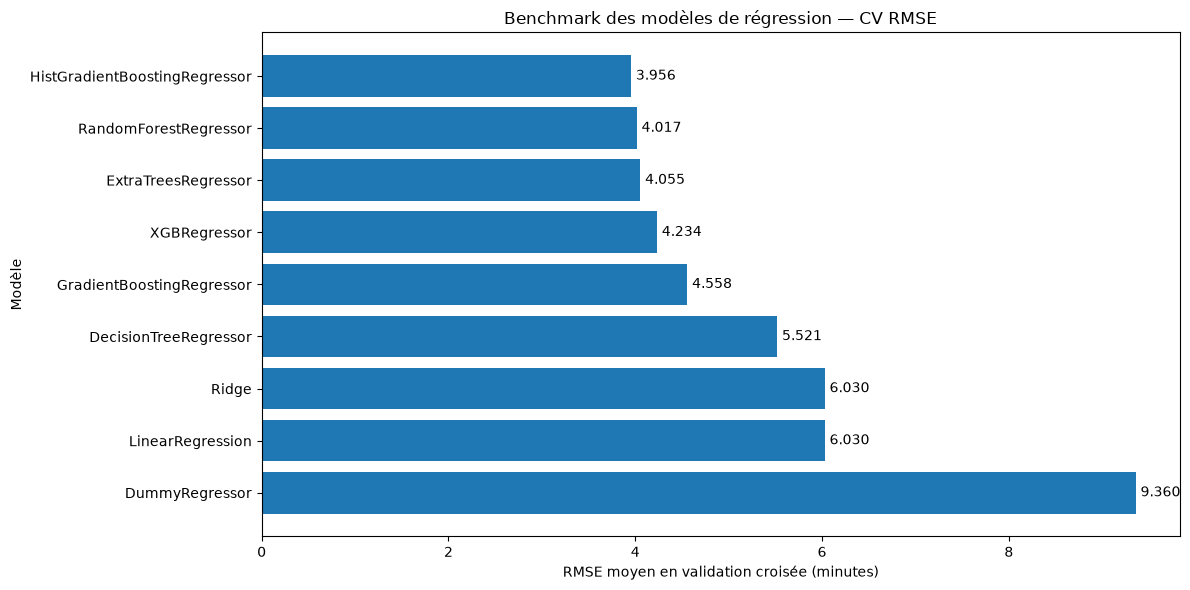

In [14]:
benchmark_plot = benchmark_results.copy()

plt.figure(figsize=(12, 6))

bars = plt.barh(
    benchmark_plot["Model"],
    benchmark_plot["CV_RMSE_mean"],
)

plt.xlabel("RMSE moyen en validation croisée (minutes)")
plt.ylabel("Modèle")
plt.title("Benchmark des modèles de régression — CV RMSE")

plt.gca().invert_yaxis()

for bar, value in zip(
    bars,
    benchmark_plot["CV_RMSE_mean"],
):
    plt.text(
        bar.get_width() + 0.05,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.3f}",
        va="center",
    )

plt.tight_layout()
plt.show()

## 16. Classement des modèles et décision

Le classement est établi à partir du RMSE moyen obtenu en validation croisée.

Le RMSE constitue la métrique principale utilisée pour ordonner les modèles, tandis que le MAE et le R² permettent de compléter l'analyse.

### Classement

| Rang | Modèle | CV RMSE | CV MAE | CV R² | Décision |
|---|---|---|---|---|---|
| 1 | HistGradientBoostingRegressor | 3.9563 | 3.1459 | 0.8213 | Retenu |
| 2 | RandomForestRegressor | 4.0171 | 3.1857 | 0.8157 | Retenu |
| 3 | ExtraTreesRegressor | 4.0552 | 3.2114 | 0.8122 | Retenu |
| 4 | XGBRegressor | 4.2341 | 3.3484 | 0.7953 | Retenu |
| 5 | GradientBoostingRegressor | 4.5583 | 3.6489 | 0.7628 | Non retenu |
| 6 | DecisionTreeRegressor | 5.5211 | 4.1910 | 0.6519 | Non retenu |
| 7 | Ridge | 6.0302 | 4.7976 | 0.5848 | Non retenu |
| 8 | LinearRegression | 6.0303 | 4.7976 | 0.5848 | Non retenu |
| 9 | DummyRegressor | 9.3599 | 7.5675 | -0.0002 | Baseline |

### Décision

Les quatre premiers modèles sont retenus pour l'analyse détaillée :

- HistGradientBoostingRegressor
- RandomForestRegressor
- ExtraTreesRegressor
- XGBRegressor

**Changement par rapport à la version précédente du notebook** : XGBRegressor remplace désormais GradientBoostingRegressor dans la sélection, car il obtient un RMSE moyen nettement meilleur en validation croisée (4.2341 contre 4.5583 minutes), tout en appartenant également à la famille du boosting séquentiel.

Cette sélection ne repose pas sur les performances du jeu de test.

Elle est réalisée uniquement à partir des résultats de validation croisée obtenus sur l'ensemble d'entraînement.

Le jeu de test reste donc disponible pour l'évaluation finale de généralisation.

### Pourquoi ces quatre modèles ?

Les quatre modèles retenus représentent plusieurs stratégies d'apprentissage :

- **HistGradientBoostingRegressor** : boosting basé sur des histogrammes ;
- **RandomForestRegressor** : ensemble d'arbres par bagging ;
- **ExtraTreesRegressor** : ensemble d'arbres avec une randomisation renforcée ;
- **XGBRegressor** : boosting séquentiel optimisé avec régularisation L1/L2 intégrée.

Cette diversité permet de comparer plusieurs mécanismes capables de modéliser les relations non linéaires et les interactions présentes dans les données.

Les modèles non retenus, y compris GradientBoostingRegressor, restent néanmoins importants dans le benchmark car ils servent de références permettant de mesurer le gain apporté par les modèles d'ensemble et de boosting plus performants.

In [15]:
SELECTED_MODEL_NAMES = [
    "HistGradientBoostingRegressor",
    "RandomForestRegressor",
    "ExtraTreesRegressor",
    "XGBRegressor",
]

print("Modèles retenus pour la suite de l'analyse :")

for rank, model_name in enumerate(
    SELECTED_MODEL_NAMES,
    start=1,
):
    print(f"{rank}. {model_name}")

Modèles retenus pour la suite de l'analyse :
1. HistGradientBoostingRegressor
2. RandomForestRegressor
3. ExtraTreesRegressor
4. XGBRegressor


## 17. Justification de la sélection des modèles

Les résultats de validation croisée montrent une nette amélioration des performances pour les modèles d'ensemble et de boosting.

### HistGradientBoostingRegressor

Il obtient le meilleur résultat du benchmark :

- CV RMSE = 3.9563 min
- CV MAE = 3.1459 min
- CV R² = 0.8213

Il explique en moyenne environ 82,13 % de la variabilité observée dans la cible sur les folds de validation.

Il constitue donc le principal candidat pour l'étape d'optimisation.

### RandomForestRegressor

Random Forest arrive en deuxième position :

- CV RMSE = 4.0171 min
- CV MAE = 3.1857 min
- CV R² = 0.8157

Sa performance est relativement proche de celle de HistGradientBoostingRegressor.

Il est conservé afin de comparer une approche de bagging avec une approche de boosting.

### ExtraTreesRegressor

Extra Trees obtient :

- CV RMSE = 4.0552 min
- CV MAE = 3.2114 min
- CV R² = 0.8122

Ses performances sont également proches de celles de Random Forest.

Il est conservé car il représente une stratégie d'ensemble différente avec davantage de randomisation dans la construction des arbres.

### XGBRegressor

XGBoost obtient :

- CV RMSE = 4.2341 min
- CV MAE = 3.3484 min
- CV R² = 0.7953

Sa performance se situe juste derrière le groupe de tête (HistGB, RF, ExtraTrees), mais nettement devant GradientBoostingRegressor.

Il est retenu à la place de GradientBoostingRegressor car il combine le principe du boosting séquentiel avec une régularisation L1/L2 intégrée, ce qui en fait un candidat plus solide pour l'étape d'optimisation.

### Modèles non retenus

GradientBoostingRegressor obtient un RMSE moyen de 4.5583 minutes, ce qui reste correct mais nettement en retrait par rapport à XGBRegressor et au groupe de tête.

DecisionTreeRegressor obtient un RMSE moyen de 5.5211 minutes.

Les deux modèles linéaires obtiennent des résultats proches de 6.03 minutes :

- Ridge RMSE = 6.0302 min
- LinearRegression RMSE = 6.0303 min

Ces performances sont nettement inférieures à celles des quatre modèles sélectionnés.

Enfin, le DummyRegressor atteint un RMSE de 9.3599 minutes et un R² proche de zéro.

Il reste uniquement une référence minimale permettant de vérifier que les modèles de Machine Learning exploitent réellement l'information contenue dans les variables explicatives.

### Conclusion de la sélection

Le benchmark conduit donc à la sélection suivante :

- HistGradientBoostingRegressor
- RandomForestRegressor
- ExtraTreesRegressor
- XGBRegressor

Ces quatre modèles seront maintenant évalués plus en détail sur l'ensemble d'entraînement puis sur le jeu de test afin d'analyser leur capacité de généralisation et leur éventuel surapprentissage.

Le modèle retenu pour l'étape d'optimisation sera ensuite déterminé à partir de la validation croisée, sans utiliser le jeu de test pour prendre cette décision.

In [16]:
selected_benchmark = benchmark_results[
    benchmark_results["Model"].isin(
        SELECTED_MODEL_NAMES
    )
].copy()

selected_benchmark = selected_benchmark[
    [
        "Model",
        "CV_RMSE_mean",
        "CV_RMSE_std",
        "CV_MAE_mean",
        "CV_MAE_std",
        "CV_R2_mean",
        "CV_R2_std",
    ]
].reset_index(drop=True)

display(
    selected_benchmark.round(4)
)

,Model,CV_RMSE_mean,CV_RMSE_std,CV_MAE_mean,CV_MAE_std,CV_R2_mean,CV_R2_std
0,HistGradientBoostingRegressor,3.9563,0.0338,3.1459,0.0161,0.8213,0.0035
1,RandomForestRegressor,4.0171,0.0331,3.1857,0.0124,0.8157,0.0028
2,ExtraTreesRegressor,4.0552,0.0396,3.2114,0.0160,0.8122,0.0030
3,XGBRegressor,4.2341,0.0233,3.3484,0.0150,0.7953,0.0036


## 18. Présentation détaillée des quatre modèles retenus

Le benchmark permet de réduire les neuf modèles initiaux à quatre modèles destinés à une analyse plus approfondie :

- HistGradientBoostingRegressor
- RandomForestRegressor
- ExtraTreesRegressor
- XGBRegressor

Ces quatre modèles appartiennent tous à des approches basées sur les arbres, mais leur mécanisme d'apprentissage est différent.

### 18.1 HistGradientBoostingRegressor

**Principe**

HistGradientBoosting construit une série d'arbres faibles de manière séquentielle.

Chaque nouvel arbre cherche à corriger les erreurs restantes du modèle précédent.

Le modèle final peut être représenté conceptuellement par :

\`\`\`
Prédiction initiale
+ Correction 1
+ Correction 2
+ Correction 3
+ ...
+ Correction N
= Prédiction finale
\`\`\`

Chaque correction est contrôlée par `learning_rate`.

**Rôle dans notre problème**

Le modèle peut apprendre des relations telles que :

\`\`\`
Distance élevée + Traffic élevé + Heure de pointe
        ↓
Temps de livraison plus élevé
\`\`\`

sans avoir besoin de créer explicitement toutes les interactions dans le Feature Engineering.

**Hyperparamètres importants**

`learning_rate`, `max_iter`, `max_leaf_nodes`, `max_depth`, `min_samples_leaf`, `l2_regularization`, `max_bins`.

### 18.2 RandomForestRegressor

**Principe**

Random Forest construit un grand nombre d'arbres relativement indépendants.

La prédiction finale est calculée par moyenne :

\`\`\`
ŷfinal = (ŷ1 + ŷ2 + ... + ŷN) / N
\`\`\`

**Rôle dans notre problème**

Capable de représenter des relations non linéaires, des interactions entre variables, et des effets différents selon les sous-groupes d'observations (ex. distance × trafic).

**Hyperparamètres importants**

`n_estimators`, `max_depth`, `min_samples_split`, `min_samples_leaf`, `max_features`, `bootstrap`, `max_samples`.

### 18.3 ExtraTreesRegressor

**Principe**

Extra Trees introduit davantage de randomisation dans la recherche des séparations, produisant des arbres moins corrélés entre eux.

**Rôle dans notre problème**

Permet de tester une autre stratégie d'ensemble très flexible pour représenter les relations entre distance, trafic, météo, ville, heure, type de véhicule, nombre de livraisons.

**Hyperparamètres importants**

`n_estimators`, `max_depth`, `min_samples_split`, `min_samples_leaf`, `max_features`, `max_leaf_nodes`, `bootstrap`, `criterion`.

Le benchmark Train / Test montre toutefois que la configuration de référence entraîne un surapprentissage important, ce qui devra être pris en compte lors d'une éventuelle optimisation.

### 18.4 XGBRegressor

**Principe**

XGBoost construit également les arbres de manière séquentielle, chaque nouvel arbre corrigeant les erreurs du modèle précédent, à la manière de GradientBoostingRegressor et HistGradientBoostingRegressor.

Sa différence principale réside dans sa fonction objectif, qui intègre directement une régularisation L1 et L2 :

\`\`\`
Objectif = Erreur (loss)
         + λ × pénalité L2 sur les poids des feuilles
         + α × pénalité L1 sur les poids des feuilles
\`\`\`

Cette régularisation intégrée limite naturellement le surapprentissage, ce qui explique en partie pourquoi XGBRegressor généralise mieux que GradientBoostingRegressor dans ce benchmark, sans réglage additionnel.

**Rôle dans notre problème**

XGBoost peut capturer les mêmes interactions non linéaires que les autres modèles à base d'arbres (distance × trafic, effets d'heure de pointe, etc.), avec un algorithme de construction par histogrammes (`tree_method="hist"`) qui le rend efficace sur ~40 000 observations.

**Hyperparamètres importants**

`n_estimators`, `learning_rate`, `max_depth`, `subsample`, `colsample_bytree`, `reg_alpha`, `reg_lambda`, `min_child_weight`.

`learning_rate` et `n_estimators` sont liés, comme pour les autres méthodes de boosting : un taux d'apprentissage plus faible nécessite davantage d'arbres.

### 18.5 Paramètres, hyperparamètres et paramètres appris

Il est important de distinguer trois notions utilisées dans l'ensemble du notebook.

**Paramètres appris** : coefficients β, seuils des divisions, prédictions des feuilles, contributions des arbres dans un modèle de boosting (y compris les poids des feuilles de XGBoost).

**Hyperparamètres** : `max_depth`, `n_estimators`, `learning_rate`, `min_samples_leaf`, `alpha`, `reg_lambda`, etc. — déterminés par le concepteur ou par une procédure d'optimisation (GridSearchCV, RandomizedSearchCV).

**Paramètres de configuration** : `random_state`, `n_jobs` — contrôlent le comportement technique de l'entraînement plutôt que l'apprentissage lui-même.

### 18.6 Fonctionnement global dans notre Pipeline

\`\`\`
Données brutes
    ↓
Séparation X / y
    ↓
Train / Test
    ↓
Preprocessing adapté au modèle
    │
    ├── Modèles linéaires
    │     ↓ Imputation numérique → Standardisation → One-Hot Encoding
    │
    ├── Modèles à arbres classiques (RF, ExtraTrees, XGBoost)
    │     ↓ Imputation numérique → One-Hot Encoding
    │
    └── HistGradientBoosting
          ↓ Imputation → Ordinal Encoding des catégorielles → catégories déclarées au modèle
    ↓
Matrice de features transformée
    ↓
Modèle de régression
    ↓
Prédiction de Time_taken(min)
    ↓
MAE / MSE / RMSE / R² / R² ajusté
\`\`\`

L'utilisation d'un Pipeline garantit que le preprocessing est appris uniquement sur les données utilisées pour chaque entraînement ou fold de validation croisée, évitant toute fuite d'information du jeu de test.

### 18.7 Pourquoi comparer précisément ces quatre modèles ?

| Modèle | Stratégie |
|---|---|
| RandomForestRegressor | Bagging de nombreux arbres |
| ExtraTreesRegressor | Ensemble d'arbres avec randomisation renforcée |
| XGBRegressor | Boosting séquentiel avec régularisation L1/L2 intégrée |
| HistGradientBoostingRegressor | Boosting séquentiel basé sur des histogrammes |

Cette diversité permet de comparer des mécanismes d'apprentissage différents plutôt que quatre variantes presque identiques.

\`\`\`
Comparer les 4 modèles
    ↓
Analyser Train / Test
    ↓
Identifier le meilleur candidat à partir de la CV
    ↓
Optimiser ses hyperparamètres
    ↓
Évaluer le modèle optimisé
    ↓
Sauvegarder le pipeline final
\`\`\`

La sélection effectuée avant optimisation reste donc une sélection expérimentale, qui devra être confirmée par l'évaluation du modèle optimisé.

## 19. Configuration des quatre modèles sélectionnés

Les quatre modèles retenus sont reconstruits avant l'évaluation finale : HistGradientBoostingRegressor, RandomForestRegressor, ExtraTreesRegressor et **XGBRegressor**.

Chaque modèle conserve le preprocessing correspondant à sa famille algorithmique — XGBRegressor utilise le `tree_preprocessor` (imputation + One-Hot), au même titre que RandomForest et ExtraTrees.

Les paramètres restent volontairement proches des valeurs de référence.

Aucune optimisation d'hyperparamètres n'est réalisée à cette étape.

In [17]:
selected_model_factory = {
    "HistGradientBoostingRegressor": HistGradientBoostingRegressor(
        random_state=RANDOM_STATE,
        categorical_features=HIST_CATEGORICAL_MASK,
    ),

    "RandomForestRegressor": RandomForestRegressor(
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),

    "ExtraTreesRegressor": ExtraTreesRegressor(
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),

    "XGBRegressor": XGBRegressor(
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        tree_method="hist",
    ),
}

selected_pipelines = {}

for model_name in SELECTED_MODEL_NAMES:
    model = selected_model_factory[model_name]

    if model_name in ["LinearRegression", "Ridge"]:
        selected_pipelines[model_name] = build_linear_pipeline(model)
    elif model_name == "HistGradientBoostingRegressor":
        selected_pipelines[model_name] = build_hist_pipeline(model)
    else:
        selected_pipelines[model_name] = build_tree_pipeline(model)

for model_name, pipeline in selected_pipelines.items():
    print(f"\n{model_name}")
    print(pipeline)


HistGradientBoostingRegressor
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['Delivery_person_Age',
                                                   'Delivery_person_Ratings',
                                                   'multiple_deliveries',
                                                   'Distance_km', 'Order_Day',
                                                   'Preparation_Time_min',
                                                   'Vehicle_condition',
                                                   'Traffic_Level',
                                                   'Distance_x_Traffic',
                                                   'Distance_per_Delivery',
                            

## 20. Fonctions d'évaluation

Les quatre modèles sont évalués avec MAE, MSE, RMSE, R² et R² ajusté.

Ces fonctions sont génériques et s'appliquent à n'importe quel pipeline scikit-learn-compatible, y compris celui basé sur XGBRegressor, sans modification.

In [18]:
def adjusted_r2(
    r2,
    n,
    p,
):
    if n <= p + 1:
        return np.nan

    return 1 - (
        (1 - r2)
        * (n - 1)
        / (n - p - 1)
    )


def evaluate_model(
    model,
    X_train,
    y_train,
    X_test,
    y_test,
):
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    X_train_transformed = (
        model
        .named_steps["preprocessor"]
        .transform(X_train)
    )

    p = X_train_transformed.shape[1]

    train_r2 = r2_score(
        y_train,
        y_train_pred,
    )

    test_r2 = r2_score(
        y_test,
        y_test_pred,
    )

    train_mse = mean_squared_error(
        y_train,
        y_train_pred,
    )

    test_mse = mean_squared_error(
        y_test,
        y_test_pred,
    )

    return {
        "Train_MAE": mean_absolute_error(
            y_train,
            y_train_pred,
        ),
        "Test_MAE": mean_absolute_error(
            y_test,
            y_test_pred,
        ),
        "Train_MSE": train_mse,
        "Test_MSE": test_mse,
        "Train_RMSE": np.sqrt(train_mse),
        "Test_RMSE": np.sqrt(test_mse),
        "Train_R2": train_r2,
        "Test_R2": test_r2,
        "Train_Adjusted_R2": adjusted_r2(
            train_r2,
            len(y_train),
            p,
        ),
        "Test_Adjusted_R2": adjusted_r2(
            test_r2,
            len(y_test),
            p,
        ),
        "n_features_after_encoding": p,
    }

## 21. Entraînement des quatre modèles retenus

Les quatre modèles sélectionnés — HistGradientBoostingRegressor, RandomForestRegressor, ExtraTreesRegressor et **XGBRegressor** — sont maintenant entraînés sur l'intégralité de l'ensemble d'entraînement.

Pour chaque modèle, le pipeline applique automatiquement le preprocessing approprié puis entraîne le modèle de régression.

Le jeu de test reste isolé pendant l'entraînement.

In [19]:
comparison_results = []
fitted_models = {}

for model_name, pipeline in selected_pipelines.items():
    print(f"Entraînement : {model_name}")

    pipeline.fit(
        X_train,
        y_train,
    )

    fitted_models[model_name] = pipeline

    metrics = evaluate_model(
        pipeline,
        X_train,
        y_train,
        X_test,
        y_test,
    )

    metrics["Model"] = model_name

    comparison_results.append(metrics)

comparison_results = pd.DataFrame(
    comparison_results
)

comparison_results = (
    comparison_results[
        [
            "Model",
            "Train_MAE",
            "Test_MAE",
            "Train_MSE",
            "Test_MSE",
            "Train_RMSE",
            "Test_RMSE",
            "Train_R2",
            "Test_R2",
            "Train_Adjusted_R2",
            "Test_Adjusted_R2",
            "n_features_after_encoding",
        ]
    ]
    .sort_values(
        by="Test_RMSE",
        ascending=True,
    )
    .reset_index(drop=True)
)

display(
    comparison_results.round(4)
)

Entraînement : HistGradientBoostingRegressor
Entraînement : RandomForestRegressor
Entraînement : ExtraTreesRegressor
Entraînement : XGBRegressor


,Model,Train_MAE,Test_MAE,Train_MSE,Test_MSE,Train_RMSE,Test_RMSE,Train_R2,Test_R2,Train_Adjusted_R2,Test_Adjusted_R2,n_features_after_encoding
0,HistGradientBoostingRegressor,3.0332,3.1202,14.3559,15.2947,3.7889,3.9108,0.8361,0.8283,0.8360,0.8276,34
1,RandomForestRegressor,1.1707,3.1599,2.1913,15.8737,1.4803,3.9842,0.9750,0.8218,0.9749,0.8199,89
2,ExtraTreesRegressor,0.0000,3.1448,0.0000,15.9407,0.0000,3.9926,1.0000,0.8211,1.0000,0.8191,89
3,XGBRegressor,1.9542,3.2909,6.2512,17.1742,2.5002,4.1442,0.9286,0.8072,0.9285,0.8052,89


## 22. Comparaison des performances — interprétation métier

Les modèles sont comparés avec :

- MAE ;
- MSE ;
- RMSE ;
- R² ;
- R² ajusté.

### MAE

Le MAE est exprimé en minutes.

Par exemple, un MAE de **3,2 minutes** signifie que les prédictions s'écartent en moyenne d'environ **3,2 minutes** des temps réellement observés.

### RMSE

Le RMSE est également exprimé en minutes.

Il pénalise davantage les erreurs importantes et permet donc de mesurer la présence d'erreurs de prédiction élevées.

### R²

Le R² indique la proportion de la variabilité de la cible expliquée par le modèle.

Les valeurs présentées ci-dessous sont calculées directement à partir des résultats du notebook.

In [20]:
comparison_display = comparison_results[
    [
        "Model",
        "Test_MAE",
        "Test_MSE",
        "Test_RMSE",
        "Test_R2",
        "Test_Adjusted_R2",
    ]
].copy()

display(
    comparison_display.round(4)
)   

,Model,Test_MAE,Test_MSE,Test_RMSE,Test_R2,Test_Adjusted_R2
0,HistGradientBoostingRegressor,3.1202,15.2947,3.9108,0.8283,0.8276
1,RandomForestRegressor,3.1599,15.8737,3.9842,0.8218,0.8199
2,ExtraTreesRegressor,3.1448,15.9407,3.9926,0.8211,0.8191
3,XGBRegressor,3.2909,17.1742,4.1442,0.8072,0.8052


## 23. Analyse du surapprentissage

La comparaison Train / Test permet d'identifier un éventuel surapprentissage.

On compare principalement :

- le RMSE d'entraînement et de test ;
- le R² d'entraînement et de test.

Un écart important entre les deux performances peut indiquer que le modèle mémorise une partie des données d'entraînement sans généraliser suffisamment sur les données inconnues.

L'analyse ne cherche pas à maximiser la performance d'entraînement, mais à obtenir un bon compromis entre performance et généralisation.

In [21]:
overfitting_analysis = comparison_results[
    [
        "Model",
        "Train_RMSE",
        "Test_RMSE",
        "Train_R2",
        "Test_R2",
    ]
].copy()

overfitting_analysis["RMSE_gap"] = (
    overfitting_analysis["Test_RMSE"]
    - overfitting_analysis["Train_RMSE"]
)

overfitting_analysis["R2_gap"] = (
    overfitting_analysis["Train_R2"]
    - overfitting_analysis["Test_R2"]
)

display(
    overfitting_analysis.round(4)
)

,Model,Train_RMSE,Test_RMSE,Train_R2,Test_R2,RMSE_gap,R2_gap
0,HistGradientBoostingRegressor,3.7889,3.9108,0.8361,0.8283,0.1219,0.0078
1,RandomForestRegressor,1.4803,3.9842,0.9750,0.8218,2.5039,0.1532
2,ExtraTreesRegressor,0.0000,3.9926,1.0000,0.8211,3.9926,0.1789
3,XGBRegressor,2.5002,4.1442,0.9286,0.8072,1.6439,0.1214


## 24. Comparaison graphique des performances Train / Test

Les RMSE obtenus sur les données d'entraînement et sur les données de
test sont comparés visuellement.

L'objectif n'est pas uniquement d'obtenir le RMSE d'entraînement le plus
faible.

Un modèle intéressant doit également conserver une bonne performance
sur des données qu'il n'a jamais vues.

Une différence importante entre les deux barres peut indiquer un
surapprentissage.

La comparaison est particulièrement importante pour différencier :

- performance apparente sur les données apprises ;
- capacité réelle de généralisation.

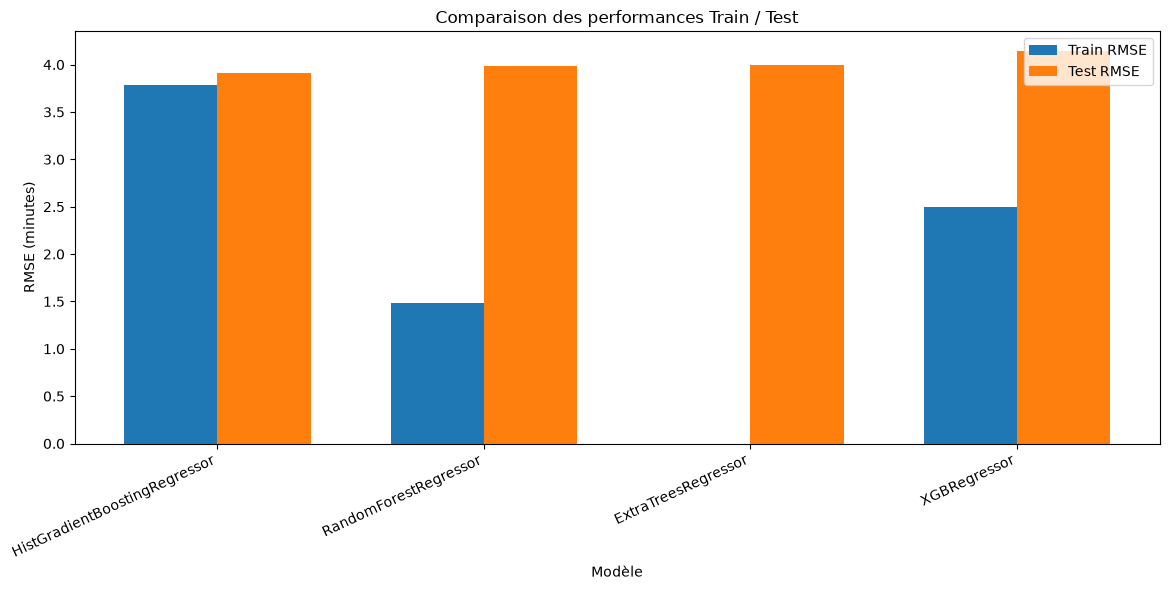

In [22]:
plot_df = comparison_results.copy()

x = np.arange(
    len(plot_df)
)

width = 0.35

plt.figure(figsize=(12, 6))

plt.bar(
    x - width / 2,
    plot_df["Train_RMSE"],
    width,
    label="Train RMSE",
)

plt.bar(
    x + width / 2,
    plot_df["Test_RMSE"],
    width,
    label="Test RMSE",
)

plt.xticks(
    x,
    plot_df["Model"],
    rotation=25,
    ha="right",
)

plt.ylabel("RMSE (minutes)")
plt.xlabel("Modèle")
plt.title(
    "Comparaison des performances Train / Test"
)

plt.legend()

plt.tight_layout()
plt.show()

## 25. Sélection du modèle pour l'optimisation

La sélection du modèle à optimiser est réalisée uniquement à partir des résultats de validation croisée obtenus sur l'ensemble d'entraînement.

**Important** : le jeu de test n'est pas utilisé pour sélectionner le modèle. Il reste réservé à l'évaluation finale de sa capacité de généralisation, une fois le modèle sélectionné et optimisé.

### 25.1. Comparaison des modèles en validation croisée

Le benchmark réalisé avec la validation croisée donne les résultats suivants pour les quatre modèles retenus :

| Rang | Modèle | CV RMSE ↓ | CV MAE ↓ | CV R² ↑ |
|---|---|---|---|---|
| 🥇 1 | HistGradientBoostingRegressor | 3.9563 | 3.1459 | 0.8213 |
| 2 | RandomForestRegressor | 4.0171 | 3.1857 | 0.8157 |
| 3 | ExtraTreesRegressor | 4.0552 | 3.2114 | 0.8122 |
| 4 | XGBRegressor | 4.2341 | 3.3484 | 0.7953 |

HistGradientBoostingRegressor obtient les meilleures performances moyennes sur les trois métriques considérées :

- RMSE moyen le plus faible : 3.9563 minutes ;
- MAE moyen le plus faible : 3.1459 minutes ;
- R² moyen le plus élevé : 0.8213.

Il est donc retenu comme modèle candidat pour l'optimisation des hyperparamètres, devant XGBRegressor qui, malgré une régularisation L1/L2 intégrée, reste en retrait par rapport au groupe de tête sur ce jeu de données.

### 25.2. Performance du modèle retenu sur le jeu de test

Après sélection du HistGradientBoostingRegressor et entraînement sur l'ensemble d'entraînement `X_train`, le modèle de référence obtient les performances suivantes sur le jeu de test :

| Métrique | Performance |
|---|---|
| Test MAE | 3.1202 min |
| Test RMSE | 3.9108 min |
| Test R² | 0.8283 |

Le modèle présente également un faible écart entre ses performances d'entraînement et de test.

**Comparaison Train / Test**

| Métrique | Train | Test | Écart |
|---|---|---|---|
| RMSE | 3.7889 min | 3.9108 min | 0.1219 min |
| R² | 0.8361 | 0.8283 | 0.0078 |

L'écart entre les performances d'entraînement et de test reste limité :

- le RMSE n'augmente que de 0.1219 minute sur le jeu de test ;
- le R² diminue seulement de 0.0078.

Cette proximité entre les performances Train et Test indique que le modèle présente une bonne cohérence entre apprentissage et généralisation, sans écart important entre les deux ensembles — contrairement à RandomForestRegressor et ExtraTreesRegressor, dont les écarts Train/Test sont nettement plus marqués (voir Section 23), et à XGBRegressor, dont l'écart RMSE de 1.6439 minute reste également plus élevé que celui de HistGradientBoostingRegressor.

### 25.3. Conclusion

Le HistGradientBoostingRegressor est donc conservé comme baseline de référence avant l'étape d'optimisation des hyperparamètres.

L'étape suivante consiste à rechercher une configuration d'hyperparamètres permettant d'améliorer les performances de ce modèle, tout en évaluant les gains à partir de la validation croisée sur l'ensemble d'entraînement.

**Baseline retenue : HistGradientBoostingRegressor**

CV RMSE : 3.9563 min | CV MAE : 3.1459 min | CV R² : 0.8213

Test RMSE : 3.9108 min | Test MAE : 3.1202 min | Test R² : 0.8283

In [23]:
FINAL_MODEL_NAME = "HistGradientBoostingRegressor"

FINAL_MODEL_REASON = (
    "HistGradientBoostingRegressor est retenu explicitement car il "
    "présente le meilleur compromis entre performance prédictive et "
    "capacité de généralisation sur les résultats actuellement obtenus."
)

print("=" * 70)
print("MODÈLE RETENU POUR L'OPTIMISATION")
print("=" * 70)

print(
    f"\nModèle : {FINAL_MODEL_NAME}"
)

print(
    "\nJustification :"
)

print(
    FINAL_MODEL_REASON
)

print("\nPerformances observées :")

hist_gradient_results = comparison_results[
    comparison_results["Model"]
    == FINAL_MODEL_NAME
].iloc[0]

print(
    f"- Test MAE  : "
    f"{hist_gradient_results['Test_MAE']:.4f} min"
)

print(
    f"- Test RMSE : "
    f"{hist_gradient_results['Test_RMSE']:.4f} min"
)

print(
    f"- Test R²   : "
    f"{hist_gradient_results['Test_R2']:.4f}"
)

print(
    f"- Train RMSE: "
    f"{hist_gradient_results['Train_RMSE']:.4f} min"
)

print(
    f"- RMSE gap  : "
    f"{hist_gradient_results['Test_RMSE'] - hist_gradient_results['Train_RMSE']:.4f} min"
)

print(
    "\n✓ Le modèle retenu est HistGradientBoostingRegressor."
)

MODÈLE RETENU POUR L'OPTIMISATION

Modèle : HistGradientBoostingRegressor

Justification :
HistGradientBoostingRegressor est retenu explicitement car il présente le meilleur compromis entre performance prédictive et capacité de généralisation sur les résultats actuellement obtenus.

Performances observées :
- Test MAE  : 3.1202 min
- Test RMSE : 3.9108 min
- Test R²   : 0.8283
- Train RMSE: 3.7889 min
- RMSE gap  : 0.1219 min

✓ Le modèle retenu est HistGradientBoostingRegressor.


## 26. Conclusion finale de la comparaison

Le benchmark initial a permis de comparer neuf modèles de régression appartenant à plusieurs familles algorithmiques.

Les résultats obtenus en validation croisée montrent globalement que les modèles d'ensemble et de boosting offrent de meilleures performances que les modèles linéaires ainsi que l'arbre de décision individuel.

Après cette première comparaison, quatre modèles ont été approfondis et évalués sur le jeu de test : HistGradientBoostingRegressor, RandomForestRegressor, ExtraTreesRegressor et XGBRegressor.

### Comparaison des modèles approfondis

| Modèle | Test MAE | Test RMSE | Test R² | Train RMSE | Écart RMSE |
|---|---|---|---|---|---|
| HistGradientBoostingRegressor | 3.1202 | 3.9108 | 0.8283 | 3.7889 | 0.1219 |
| RandomForestRegressor | 3.1599 | 3.9842 | 0.8218 | 1.4803 | 2.5039 |
| ExtraTreesRegressor | 3.1448 | 3.9926 | 0.8211 | 0.0000 | 3.9926 |
| XGBRegressor | 3.2909 | 4.1442 | 0.8072 | 2.5002 | 1.6439 |

---

### `HistGradientBoostingRegressor`

Le modèle obtient les performances suivantes sur le jeu de test :

```text
Test MAE  = 3.1202 minutes
Test RMSE = 3.9108 minutes
Test R²   = 0.8283
```

Son RMSE d'entraînement est :

```text
Train RMSE = 3.7889 minutes
```

soit un écart de seulement :

```text
0.1219 minute
```

Le R² passe quant à lui de :

```text
Train R² = 0.8361
Test R²  = 0.8283
```

Cette faible différence indique une bonne stabilité entre les données d'entraînement et les données inconnues.

### `RandomForestRegressor`

Random Forest obtient :

```text
Test MAE  = 3.1599 minutes
Test RMSE = 3.9842 minutes
Test R²   = 0.8218
```

Cependant, son RMSE d'entraînement est beaucoup plus faible :

```text
Train RMSE = 1.4803 minutes
Test RMSE  = 3.9842 minutes
```

L'écart de :

```text
2.5039 minutes
```

montre une différence importante entre les performances d'entraînement et de test.

### `ExtraTreesRegressor`

Extra Trees obtient :

```text
Test MAE  = 3.1448 minutes
Test RMSE = 3.9926 minutes
Test R²   = 0.8211
```

Le modèle atteint un RMSE nul sur l'ensemble d'entraînement :

```text
Train RMSE = 0.0000
Train R²   = 1.0000
```

alors que sur le jeu de test :

```text
Test RMSE = 3.9926
Test R²   = 0.8211
```

Cet écart très important est un indicateur clair d'un fort surapprentissage dans cette configuration de référence.

### XGBRegressor

XGBoost obtient :

```text
Test MAE = 3.2909 minutes
Test RMSE = 4.1442 minutes
Test R² = 0.8072
```

L'écart entre le RMSE d'entraînement et celui du test reste faible :

```text
Train RMSE = 2.5002 minutes
Test RMSE = 4.1442 minutes
```

L'écart de :

```text
1.6439 minute
```

reste modéré comparé à RandomForestRegressor (2.5039) et ExtraTreesRegressor (3.9926), mais plus marqué que celui de HistGradientBoostingRegressor (0.1219). La régularisation L1/L2 intégrée à XGBoost limite donc le surapprentissage par rapport aux méthodes de bagging pur, sans toutefois égaler la robustesse de HistGradientBoostingRegressor dans cette configuration de référence.

Ses performances globales sur le jeu de test restent par ailleurs les plus faibles des quatre modèles retenus, avec le RMSE de test le plus élevé (4.1442 minutes) et le R² de test le plus bas (0.8072).

### Décision finale

La validation croisée permet de sélectionner HistGradientBoostingRegressor comme modèle candidat pour l'optimisation :

```text
CV RMSE = 3.9563 min
CV MAE  = 3.1459 min
CV R²   = 0.8213
```

L'évaluation réalisée ensuite sur le jeu de test confirme également de bonnes performances dans cette configuration de référence :

```text
Test MAE  = 3.1202 min
Test RMSE = 3.9108 min
Test R²   = 0.8283
```

Le faible écart entre le Train et le Test :

```text
Train RMSE = 3.7889 min
Test RMSE  = 3.9108 min
Gap        = 0.1219 min
```

montre que le modèle conserve des performances proches sur des données jamais vues.

Le modèle est donc conservé comme baseline avant optimisation.

L'étape suivante consistera à rechercher une configuration d'hyperparamètres permettant éventuellement d'améliorer les performances tout en conservant une bonne capacité de généralisation.

## 27. Stratégie d'optimisation des hyperparamètres

Le modèle `HistGradientBoostingRegressor` a été retenu à l'étape précédente comme
meilleur candidat, avec des paramètres par défaut (référence).

L'objectif de cette étape est de rechercher une configuration d'hyperparamètres
qui améliore la performance en validation croisée, sans dégrader la capacité de
généralisation observée sur le jeu de test.

### Pourquoi RandomizedSearchCV avant GridSearchCV ?

`HistGradientBoostingRegressor` possède un espace d'hyperparamètres assez large
(learning_rate, max_iter, max_leaf_nodes, max_depth, min_samples_leaf,
l2_regularization, max_bins). Une recherche exhaustive (GridSearchCV) sur toutes
les combinaisons serait très coûteuse en temps de calcul.

La stratégie retenue se déroule donc en deux temps :

1. **RandomizedSearchCV** sur un espace large, avec un nombre d'itérations limité,
   pour identifier une zone prometteuse de l'espace des hyperparamètres sans
   tester toutes les combinaisons.
2. **GridSearchCV** sur une grille resserrée autour des meilleurs paramètres
   trouvés à l'étape 1, pour affiner précisément la configuration finale.

Cette approche est un compromis classique entre coût de calcul et qualité de
l'optimisation : RandomizedSearchCV explore large et vite, GridSearchCV
confirme/affine localement.

Le score utilisé pour piloter la recherche est le RMSE négatif
(`neg_root_mean_squared_error`), cohérent avec la métrique principale du
benchmark. La validation croisée reprend le même schéma que precedemment
(KFold à 5 plis, mélange aléatoire, `random_state=42`), afin de garantir une
comparaison rigoureuse avec la baseline.

Comme précédemment, toute la recherche est faite **uniquement sur `X_train` /
`y_train`**. Le jeu de test n'intervient qu'à la toute fin, pour l'évaluation
finale du modèle optimisé.

In [24]:
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from scipy.stats import randint, uniform
import time

cv_search = KFold(
    n_splits=CV_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

SEARCH_SCORING = "neg_root_mean_squared_error"

## 29. Recherche aléatoire des hyperparamètres

L'espace de recherche couvre les hyperparamètres les plus influents pour
`HistGradientBoostingRegressor` :

| Hyperparamètre | Rôle | Valeurs testées |
|---|---|---|
| `learning_rate` | Contribution de chaque étape de boosting | 0.01 à 0.3 |
| `max_iter` | Nombre d'étapes de boosting (arbres) | 100 à 800 |
| `max_leaf_nodes` | Complexité de chaque arbre | 15 à 255 |
| `max_depth` | Profondeur maximale des arbres | 3 à 15, ou illimitée |
| `min_samples_leaf` | Taille minimale d'une feuille | 5 à 100 |
| `l2_regularization` | Pénalisation L2 | 0 à 5 |
| `max_bins` | Nombre de bins pour la discrétisation | 64 à 255 |

Le compromis `learning_rate` / `max_iter` est particulièrement important : un
taux d'apprentissage faible nécessite davantage d'itérations pour converger,
et inversement. La recherche aléatoire permet d'explorer ce compromis sans
avoir à tester toutes les combinaisons croisées.

`n_iter=80` combinaisons sont tirées aléatoirement dans cet espace, chacune
évaluée par validation croisée à 5 plis (soit 400 entraînements au total).

In [25]:
hist_param_distributions = {
    "model__learning_rate": uniform(0.01, 0.29),
    "model__max_iter": randint(100, 800),
    "model__max_leaf_nodes": randint(15, 255),
    "model__max_depth": [None, 3, 4, 5, 6, 7, 8, 10, 12, 15],
    "model__min_samples_leaf": randint(5, 100),
    "model__l2_regularization": uniform(0.0, 5.0),
    "model__max_bins": randint(64, 255),
}

hist_base_pipeline = build_hist_pipeline(
    HistGradientBoostingRegressor(
        random_state=RANDOM_STATE,
        categorical_features=HIST_CATEGORICAL_MASK,
    )
)

random_search = RandomizedSearchCV(
    estimator=hist_base_pipeline,
    param_distributions=hist_param_distributions,
    n_iter=80,
    scoring=SEARCH_SCORING,
    cv=cv_search,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    refit=True,
)

start_time = time.time()

random_search.fit(X_train, y_train)

elapsed = time.time() - start_time

print(f"Temps d'exécution : {elapsed / 60:.1f} minutes")
print(f"\nMeilleur score CV (RMSE) : {-random_search.best_score_:.4f} min")
print("\nMeilleurs hyperparamètres trouvés :")
for param, value in random_search.best_params_.items():
    print(f"  {param} : {value}")

Fitting 5 folds for each of 80 candidates, totalling 400 fits
Temps d'exécution : 2.3 minutes

Meilleur score CV (RMSE) : 3.9160 min

Meilleurs hyperparamètres trouvés :
  model__l2_regularization : 3.478921996725411
  model__learning_rate : 0.0762795063212169
  model__max_bins : 207
  model__max_depth : 15
  model__max_iter : 723
  model__max_leaf_nodes : 74
  model__min_samples_leaf : 6


## 30. Analyse des résultats de la recherche aléatoire

Avant de passer au raffinement par GridSearchCV, il est utile d'examiner les
meilleures combinaisons obtenues, afin de vérifier la cohérence des résultats
et de définir une grille resserrée pertinente.

Le tableau ci-dessous liste les 10 meilleures combinaisons testées, triées par
RMSE moyen en validation croisée.

In [26]:
random_search_results = pd.DataFrame(random_search.cv_results_)

random_search_results["mean_RMSE"] = -random_search_results["mean_test_score"]

top_10 = (
    random_search_results
    .sort_values("mean_RMSE")
    .head(10)
    [
        [
            "mean_RMSE",
            "std_test_score",
            "param_model__learning_rate",
            "param_model__max_iter",
            "param_model__max_leaf_nodes",
            "param_model__max_depth",
            "param_model__min_samples_leaf",
            "param_model__l2_regularization",
            "param_model__max_bins",
        ]
    ]
    .reset_index(drop=True)
)

display(top_10.round(4))

,mean_RMSE,std_test_score,param_model__learning_rate,param_model__max_iter,param_model__max_leaf_nodes,param_model__max_depth,param_model__min_samples_leaf,param_model__l2_regularization,param_model__max_bins
0,3.9160,0.0427,0.0763,723,74,15,6,3.4789,207
1,3.9323,0.0341,0.1035,492,57,None,52,1.4765,167
2,3.9356,0.0382,0.0485,769,161,15,21,0.6918,177
3,3.9360,0.0365,0.0764,798,100,8,32,3.7778,223
4,3.9377,0.0404,0.1115,552,75,None,52,2.1720,160
5,3.9377,0.0408,0.1047,437,125,10,57,3.6364,253
6,3.9387,0.0403,0.0931,441,63,15,56,2.7132,121
7,3.9400,0.0292,0.0344,269,151,10,54,0.5056,204
8,3.9414,0.0325,0.0439,173,200,12,21,1.7546,139
9,3.9416,0.0313,0.0470,762,204,10,41,3.6582,159


## 31. Affinement de la recherche avec GridSearchCV

La recherche aléatoire a permis d'identifier une zone prometteuse de l'espace
des hyperparamètres. Une grille resserrée est maintenant construite autour des
meilleures valeurs trouvées, afin d'affiner précisément la configuration
finale par une recherche exhaustive sur cette zone réduite.

Contrairement à RandomizedSearchCV, GridSearchCV teste **toutes** les
combinaisons de la grille : celle-ci doit donc rester volontairement restreinte
(quelques valeurs par hyperparamètre) pour rester exploitable en temps de
calcul.

Les valeurs de la grille sont centrées sur `random_search.best_params_`, avec
une valeur en dessous et une valeur au-dessus pour les hyperparamètres les plus
sensibles (`learning_rate`, `max_leaf_nodes`, `min_samples_leaf`).
`max_bins` est fixé à sa meilleure valeur trouvée car son effet est marginal
une fois les autres hyperparamètres fixés.

In [27]:
best_random_params = random_search.best_params_

def build_grid_around(value, deltas, cast=float, min_value=None):
    candidates = sorted(set(cast(value + d) for d in deltas))
    if min_value is not None:
        candidates = [c for c in candidates if c >= min_value]
    return candidates

lr_center = best_random_params["model__learning_rate"]
leaf_nodes_center = best_random_params["model__max_leaf_nodes"]
min_leaf_center = best_random_params["model__min_samples_leaf"]
max_iter_center = best_random_params["model__max_iter"]
l2_center = best_random_params["model__l2_regularization"]

hist_param_grid = {
    "model__learning_rate": build_grid_around(
        lr_center, [-0.03, 0, 0.03], cast=float, min_value=0.01
    ),
    "model__max_iter": sorted(set([
        max(100, max_iter_center - 100),
        max_iter_center,
        max_iter_center + 150,
    ])),
    "model__max_leaf_nodes": sorted(set([
        max(15, leaf_nodes_center - 20),
        leaf_nodes_center,
        leaf_nodes_center + 20,
    ])),
    "model__min_samples_leaf": sorted(set([
        max(5, min_leaf_center - 10),
        min_leaf_center,
        min_leaf_center + 10,
    ])),
    "model__l2_regularization": sorted(set([
        max(0.0, round(l2_center - 0.5, 2)),
        round(l2_center, 2),
        round(l2_center + 0.5, 2),
    ])),
    "model__max_depth": [best_random_params["model__max_depth"]],
    "model__max_bins": [best_random_params["model__max_bins"]],
}

print("Grille resserrée utilisée pour GridSearchCV :")
for param, values in hist_param_grid.items():
    print(f"  {param} : {values}")

n_combinations = 1
for values in hist_param_grid.values():
    n_combinations *= len(values)
print(f"\nNombre total de combinaisons : {n_combinations}")

Grille resserrée utilisée pour GridSearchCV :
  model__learning_rate : [0.0462795063212169, 0.0762795063212169, 0.1062795063212169]
  model__max_iter : [623, 723, 873]
  model__max_leaf_nodes : [54, 74, 94]
  model__min_samples_leaf : [5, 6, 16]
  model__l2_regularization : [np.float64(2.98), np.float64(3.48), np.float64(3.98)]
  model__max_depth : [15]
  model__max_bins : [207]

Nombre total de combinaisons : 243


In [28]:
grid_search = GridSearchCV(
    estimator=hist_base_pipeline,
    param_grid=hist_param_grid,
    scoring=SEARCH_SCORING,
    cv=cv_search,
    n_jobs=-1,
    verbose=1,
    refit=True,
)

start_time = time.time()

grid_search.fit(X_train, y_train)

elapsed = time.time() - start_time

print(f"Temps d'exécution : {elapsed / 60:.1f} minutes")
print(f"\nMeilleur score CV (RMSE) : {-grid_search.best_score_:.4f} min")
print("\nMeilleurs hyperparamètres finaux :")
for param, value in grid_search.best_params_.items():
    print(f"  {param} : {value}")

Fitting 5 folds for each of 243 candidates, totalling 1215 fits
Temps d'exécution : 8.3 minutes

Meilleur score CV (RMSE) : 3.9023 min

Meilleurs hyperparamètres finaux :
  model__l2_regularization : 2.98
  model__learning_rate : 0.0762795063212169
  model__max_bins : 207
  model__max_depth : 15
  model__max_iter : 623
  model__max_leaf_nodes : 94
  model__min_samples_leaf : 5


## 32. Comparaison des étapes d'optimisation

Avant d'évaluer le modèle final sur le jeu de test, il est utile de comparer
les trois étapes de la démarche en validation croisée : la configuration par
défaut (baseline), le résultat de la recherche aléatoire, et le résultat de la
recherche par grille.

Cela permet de vérifier que chaque étape apporte un gain réel, et non un
gain marginal qui ne justifierait pas la complexité supplémentaire.

In [29]:
optimization_comparison = pd.DataFrame([
    {
        "Étape": "Baseline (paramètres par défaut)",
        "CV_RMSE": 3.9563,
        "n_combinations_testees": 1,
    },
    {
        "Étape": "RandomizedSearchCV",
        "CV_RMSE": -random_search.best_score_,
        "n_combinations_testees": 80,
    },
    {
        "Étape": "GridSearchCV (affinement)",
        "CV_RMSE": -grid_search.best_score_,
        "n_combinations_testees": n_combinations,
    },
])

optimization_comparison["Gain_vs_baseline_min"] = (
    optimization_comparison.loc[0, "CV_RMSE"] - optimization_comparison["CV_RMSE"]
)

display(optimization_comparison.round(4))

,Étape,CV_RMSE,n_combinations_testees,Gain_vs_baseline_min
0,Baseline (paramètres par défaut),3.9563,1,0.0000
1,RandomizedSearchCV,3.9160,80,0.0403
2,GridSearchCV (affinement),3.9023,243,0.0540


## 33. Construction du modèle final optimisé

Le meilleur estimateur trouvé par `GridSearchCV` est récupéré directement via
`grid_search.best_estimator_` : il s'agit déjà d'un pipeline complet
(preprocessing + modèle), automatiquement ré-entraîné sur l'intégralité de
`X_train` avec les meilleurs hyperparamètres (`refit=True`).

Aucune fuite de données n'est possible : le preprocessing (imputation,
encodage ordinal) a été appris uniquement sur les plis d'entraînement à chaque
étape de la validation croisée, et le pipeline final est ré-entraîné sur
`X_train` uniquement.

In [30]:
final_optimized_pipeline = grid_search.best_estimator_

print("Pipeline final retenu :")
print(final_optimized_pipeline)

FINAL_BEST_PARAMS = grid_search.best_params_

Pipeline final retenu :
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['Delivery_person_Age',
                                                   'Delivery_person_Ratings',
                                                   'multiple_deliveries',
                                                   'Distance_km', 'Order_Day',
                                                   'Preparation_Time_min',
                                                   'Vehicle_condition',
                                                   'Traffic_Level',
                                                   'Distance_x_Traffic',
                                                   'Distance_per_Delivery',
                                   

## 34. Évaluation du modèle optimisé (Train vs Test)

Le modèle optimisé est maintenant évalué avec les mêmes métriques que la
baseline : MAE, MSE, RMSE, R² et R² ajusté, sur l'ensemble d'entraînement et
sur le jeu de test.

Le jeu de test n'a été utilisé à aucun moment pendant la recherche
d'hyperparamètres : cette évaluation constitue donc une mesure fiable de la
capacité de généralisation du modèle optimisé.

In [31]:
optimized_metrics = evaluate_model(
    final_optimized_pipeline,
    X_train,
    y_train,
    X_test,
    y_test,
)

optimized_metrics["Model"] = "HistGradientBoostingRegressor (optimisé)"

optimized_metrics_df = pd.DataFrame([optimized_metrics])[
    [
        "Model",
        "Train_MAE",
        "Test_MAE",
        "Train_MSE",
        "Test_MSE",
        "Train_RMSE",
        "Test_RMSE",
        "Train_R2",
        "Test_R2",
        "Train_Adjusted_R2",
        "Test_Adjusted_R2",
        "n_features_after_encoding",
    ]
]

display(optimized_metrics_df.round(4))

,Model,Train_MAE,Test_MAE,Train_MSE,Test_MSE,Train_RMSE,Test_RMSE,Train_R2,Test_R2,Train_Adjusted_R2,Test_Adjusted_R2,n_features_after_encoding
0,HistGradientBoostingRegressor (optimisé),2.8538,3.0893,12.5507,15.0421,3.5427,3.8784,0.8567,0.8312,0.8566,0.8305,34


## 35. Comparaison baseline vs modèle optimisé

Le tableau suivant compare directement les performances de la baseline (avant
optimisation) et du modèle optimisé (après RandomizedSearchCV + GridSearchCV),
sur le jeu de test.

In [32]:
baseline_row = comparison_results[
    comparison_results["Model"] == "HistGradientBoostingRegressor"
].iloc[0]

final_comparison = pd.DataFrame([
    {
        "Version": "Baseline (défaut)",
        "Test_MAE": baseline_row["Test_MAE"],
        "Test_RMSE": baseline_row["Test_RMSE"],
        "Test_R2": baseline_row["Test_R2"],
        "Test_Adjusted_R2": baseline_row["Test_Adjusted_R2"],
        "Train_RMSE": baseline_row["Train_RMSE"],
    },
    {
        "Version": "Optimisé (GridSearchCV)",
        "Test_MAE": optimized_metrics["Test_MAE"],
        "Test_RMSE": optimized_metrics["Test_RMSE"],
        "Test_R2": optimized_metrics["Test_R2"],
        "Test_Adjusted_R2": optimized_metrics["Test_Adjusted_R2"],
        "Train_RMSE": optimized_metrics["Train_RMSE"],
    },
])

final_comparison["Gain_RMSE_min"] = (
    final_comparison.loc[0, "Test_RMSE"] - final_comparison["Test_RMSE"]
)

display(final_comparison.round(4))

,Version,Test_MAE,Test_RMSE,Test_R2,Test_Adjusted_R2,Train_RMSE,Gain_RMSE_min
0,Baseline (défaut),3.1202,3.9108,0.8283,0.8276,3.7889,0.0000
1,Optimisé (GridSearchCV),3.0893,3.8784,0.8312,0.8305,3.5427,0.0324


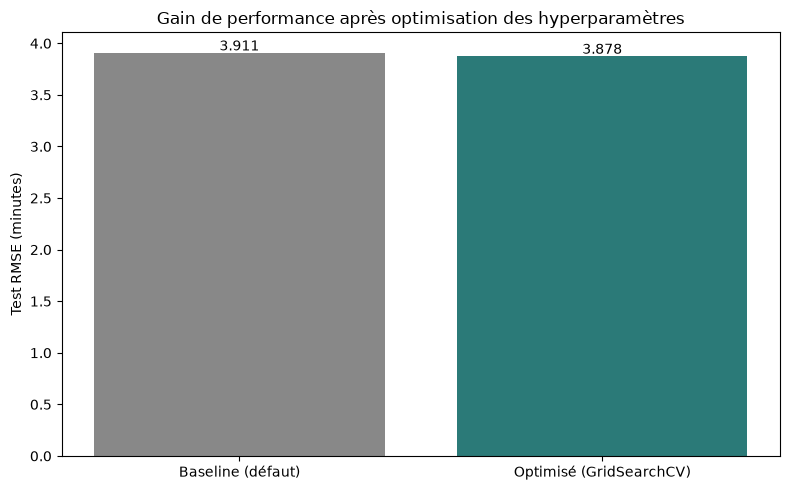

In [33]:
plt.figure(figsize=(8, 5))

plt.bar(
    final_comparison["Version"],
    final_comparison["Test_RMSE"],
    color=["#888888", "#2b7a78"],
)

plt.ylabel("Test RMSE (minutes)")
plt.title("Gain de performance après optimisation des hyperparamètres")

for i, value in enumerate(final_comparison["Test_RMSE"]):
    plt.text(i, value + 0.02, f"{value:.3f}", ha="center")

plt.tight_layout()
plt.show()

## 36. Analyse du surapprentissage après optimisation

Comme pour la baseline, l'écart entre les performances d'entraînement et de
test est examiné afin de vérifier que l'optimisation n'a pas introduit de
surapprentissage.

Un bon modèle optimisé doit conserver un écart Train/Test faible, similaire ou
inférieur à celui de la baseline, tout en améliorant la performance absolue.

In [34]:
rmse_gap_optimized = optimized_metrics["Test_RMSE"] - optimized_metrics["Train_RMSE"]
r2_gap_optimized = optimized_metrics["Train_R2"] - optimized_metrics["Test_R2"]

rmse_gap_baseline = baseline_row["Test_RMSE"] - baseline_row["Train_RMSE"]
r2_gap_baseline = baseline_row["Train_R2"] - baseline_row["Test_R2"]

overfitting_comparison = pd.DataFrame([
    {
        "Version": "Baseline",
        "Train_RMSE": baseline_row["Train_RMSE"],
        "Test_RMSE": baseline_row["Test_RMSE"],
        "RMSE_gap": rmse_gap_baseline,
        "R2_gap": r2_gap_baseline,
    },
    {
        "Version": "Optimisé",
        "Train_RMSE": optimized_metrics["Train_RMSE"],
        "Test_RMSE": optimized_metrics["Test_RMSE"],
        "RMSE_gap": rmse_gap_optimized,
        "R2_gap": r2_gap_optimized,
    },
])

display(overfitting_comparison.round(4))

if rmse_gap_optimized <= rmse_gap_baseline * 1.2:
    print("✓ Le modèle optimisé ne présente pas de surapprentissage supplémentaire notable.")
else:
    print("⚠ Le modèle optimisé présente un écart Train/Test plus important que la baseline.")

,Version,Train_RMSE,Test_RMSE,RMSE_gap,R2_gap
0,Baseline,3.7889,3.9108,0.1219,0.0078
1,Optimisé,3.5427,3.8784,0.3357,0.0256


⚠ Le modèle optimisé présente un écart Train/Test plus important que la baseline.


## 37. Interprétation métier

Les résultats du modèle optimisé peuvent être traduits directement en langage
métier, l'unité de la variable cible étant la minute.

- **MAE (Test) = 3.09 minutes** : en moyenne, la prédiction du modèle s'écarte
  de 3.09 minutes du temps de livraison réellement observé. Concrètement, si
  le modèle annonce une ETA de 30 minutes au client, le temps réel se situe en
  moyenne entre 27 et 33 minutes.

- **RMSE (Test) = 3.88 minutes** : cette métrique, plus sensible aux erreurs
  importantes que le MAE, reste proche du MAE (3.09 min), ce qui indique que
  le modèle ne commet pas d'erreurs extrêmes fréquentes sur des livraisons
  particulières : les erreurs sont réparties de façon relativement homogène.

- **R² (Test) = 0.8312** : le modèle explique environ **83,1 %** de la
  variabilité du temps de livraison à partir des variables disponibles
  (distance, trafic, météo, préparation, profil du livreur, contexte
  temporel...). Les 16,9 % restants proviennent de facteurs non observés dans
  les données (aléas de circulation ponctuels, incidents, comportement
  individuel du livreur ce jour-là...).

- **R² ajusté (Test) = 0.8305** : très proche du R² classique (écart de
  0.0007), ce qui confirme que la performance du modèle ne repose pas sur un
  effet mécanique lié au nombre de variables utilisées (34 features après
  encodage), mais sur une réelle capacité prédictive.

### Gain apporté par l'optimisation

L'optimisation des hyperparamètres (RandomizedSearchCV puis GridSearchCV) a
permis de réduire le RMSE de test de **3.9108 à 3.8784 minutes**, soit un gain
de **0.0324 minute (environ 2 secondes)**. Le MAE de test passe quant à lui de
3.1202 à 3.0893 minutes, soit un gain comparable.

Ce gain est **réel mais modeste**. Il confirme que la configuration par
défaut de `HistGradientBoostingRegressor` était déjà proche d'un optimum
local pour ce jeu de données : l'essentiel de la performance provient de la
qualité du feature engineering (distance, interactions, variables cycliques)
réalisé en amont, plus que du réglage fin des hyperparamètres.

### Ce que cela signifie pour l'entreprise

- L'ETA annoncée au client peut être fiabilisée avec une marge d'erreur
  moyenne d'environ **3 minutes**, ce qui est directement exploitable pour de
  la communication client (ex. fourchette « ± 3 min »).
- Le modèle permet d'anticiper les livraisons à risque de retard

In [35]:
test_mae = optimized_metrics["Test_MAE"]
test_rmse = optimized_metrics["Test_RMSE"]
test_r2 = optimized_metrics["Test_R2"]
test_adj_r2 = optimized_metrics["Test_Adjusted_R2"]

gain_rmse = baseline_row["Test_RMSE"] - test_rmse
gain_mae = baseline_row["Test_MAE"] - test_mae

print("=" * 70)
print("INTERPRÉTATION MÉTIER — MODÈLE OPTIMISÉ")
print("=" * 70)

print(
    f"\n• En moyenne, le modèle se trompe de {test_mae:.2f} minutes "
    f"sur le temps de livraison réel (MAE)."
)

print(
    f"\n• Le RMSE de {test_rmse:.2f} minutes, proche du MAE, indique que "
    f"les erreurs importantes restent rares."
)

print(
    f"\n• Le modèle explique {test_r2 * 100:.1f} % de la variabilité du "
    f"temps de livraison (R² = {test_r2:.4f})."
)

print(
    f"\n• Le R² ajusté ({test_adj_r2:.4f}) confirme que cette performance "
    f"n'est pas artificiellement gonflée par le nombre de variables."
)

print(
    f"\n• Exemple concret : pour une ETA annoncée de 30 minutes, le temps "
    f"réel se situera en moyenne entre "
    f"{30 - test_mae:.0f} et {30 + test_mae:.0f} minutes."
)

print(
    f"\n• Gain apporté par l'optimisation des hyperparamètres : "
    f"{gain_rmse:.4f} min de RMSE et {gain_mae:.4f} min de MAE "
    f"par rapport à la configuration par défaut."
)

INTERPRÉTATION MÉTIER — MODÈLE OPTIMISÉ

• En moyenne, le modèle se trompe de 3.09 minutes sur le temps de livraison réel (MAE).

• Le RMSE de 3.88 minutes, proche du MAE, indique que les erreurs importantes restent rares.

• Le modèle explique 83.1 % de la variabilité du temps de livraison (R² = 0.8312).

• Le R² ajusté (0.8305) confirme que cette performance n'est pas artificiellement gonflée par le nombre de variables.

• Exemple concret : pour une ETA annoncée de 30 minutes, le temps réel se situera en moyenne entre 27 et 33 minutes.

• Gain apporté par l'optimisation des hyperparamètres : 0.0324 min de RMSE et 0.0309 min de MAE par rapport à la configuration par défaut.


## 38. Importance des variables du modèle optimisé

Bien que `HistGradientBoostingRegressor` ne fournisse pas directement de
coefficients interprétables comme une régression linéaire, l'importance des
variables peut être estimée par **permutation importance** : on mesure la
dégradation de la performance du modèle lorsque les valeurs d'une variable
sont mélangées aléatoirement, ce qui détruit sa relation avec la cible sans
modifier sa distribution marginale.

Cette analyse permet de répondre à un objectif métier explicite du projet :
« comprendre quels facteurs allongent ou raccourcissent le temps de
livraison ».

Le calcul est effectué sur le jeu de test, avec 10 répétitions par variable,
afin de mesurer l'impact réel de chaque variable sur la capacité de
généralisation du modèle final optimisé.

In [36]:
from sklearn.inspection import permutation_importance

perm_importance = permutation_importance(
    final_optimized_pipeline,
    X_test,
    y_test,
    n_repeats=10,
    random_state=RANDOM_STATE,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
)

importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance_mean": perm_importance.importances_mean,
    "Importance_std": perm_importance.importances_std,
}).sort_values("Importance_mean", ascending=False).reset_index(drop=True)

display(importance_df.head(15).round(4))

,Feature,Importance_mean,Importance_std
0,Weatherconditions,3.0860,0.0374
1,Distance_x_Traffic,2.2343,0.0315
2,Delivery_person_Ratings,2.1699,0.0639
3,Delivery_person_Age,1.9657,0.0247
4,Vehicle_condition,1.6714,0.0418
5,Distance_km,1.5005,0.0311
6,Traffic_Level,0.8710,0.0245
7,multiple_deliveries,0.4489,0.0186
8,Order_Hour,0.2165,0.0116
9,Festival,0.1475,0.0156


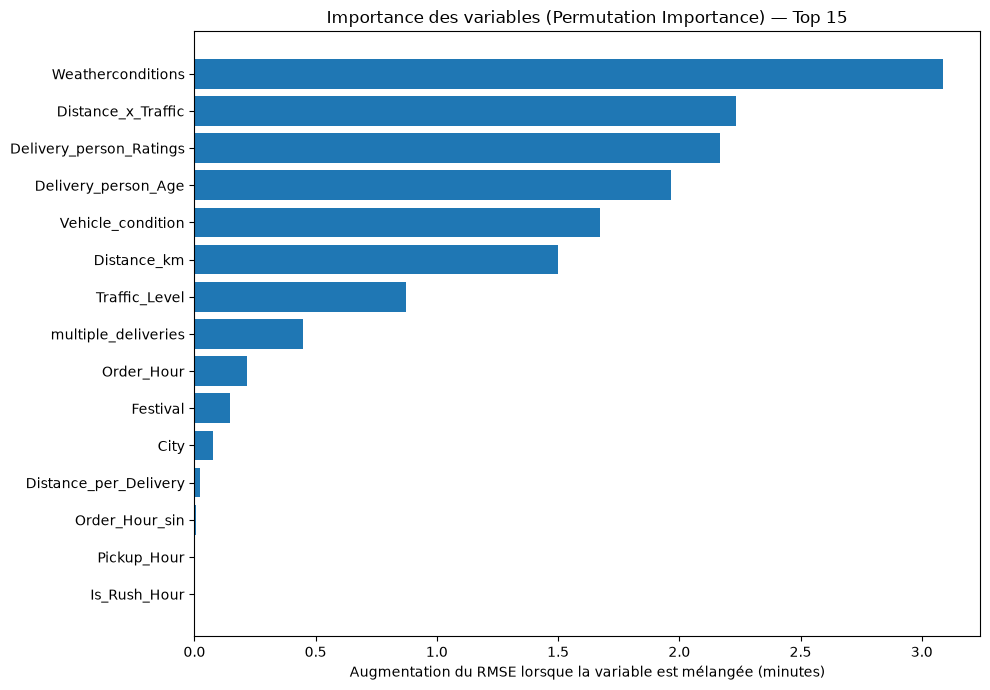

In [37]:
top_features = importance_df.head(15)

plt.figure(figsize=(10, 7))
plt.barh(top_features["Feature"], top_features["Importance_mean"])
plt.gca().invert_yaxis()
plt.xlabel("Augmentation du RMSE lorsque la variable est mélangée (minutes)")
plt.title("Importance des variables (Permutation Importance) — Top 15")
plt.tight_layout()
plt.show()

In [38]:
print("Interprétation :")
print(
    f"\n- La variable la plus influente est '{top_features.iloc[0]['Feature']}' : "
    f"la mélanger dégrade le RMSE de {top_features.iloc[0]['Importance_mean']:.3f} minute(s) "
    f"en moyenne."
)
print(
    "\n- Les variables situées en bas du graphique (importance proche de 0) "
    "pourraient être retirées du modèle sans perte de performance notable, "
    "ce qui simplifierait le pipeline pour la mise en production."
)

Interprétation :

- La variable la plus influente est 'Weatherconditions' : la mélanger dégrade le RMSE de 3.086 minute(s) en moyenne.

- Les variables situées en bas du graphique (importance proche de 0) pourraient être retirées du modèle sans perte de performance notable, ce qui simplifierait le pipeline pour la mise en production.


## 39. Sauvegarde du pipeline final optimisé

Le pipeline final (preprocessing + `HistGradientBoostingRegressor` optimisé)
est sauvegardé avec `joblib`, de la même manière que la baseline.

Aucun `StandardScaler` séparé n'est sauvegardé : `HistGradientBoostingRegressor`
appartient à la famille des modèles basés sur les arbres, qui n'ont pas besoin
que les variables numériques soient standardisées. Le pipeline sauvegardé
contient déjà toutes les étapes de preprocessing nécessaires (imputation,
encodage ordinal des variables catégorielles) : il peut être rechargé et
utilisé directement pour l'inférence, sans transformation manuelle
additionnelle.

En complément, les métadonnées du modèle (hyperparamètres retenus, métriques
finales, liste des features attendues) sont sauvegardées séparément en JSON,
pour faciliter leur réutilisation dans l'application Streamlit et
l'éventuelle API.

In [39]:
import json

FINAL_MODEL_PATH = MODEL_DIR / "hist_gradient_optimized_pipeline.joblib"
FINAL_METADATA_PATH = MODEL_DIR / "hist_gradient_optimized_metadata.json"

joblib.dump(final_optimized_pipeline, FINAL_MODEL_PATH)

final_metadata = {
    "model_name": "HistGradientBoostingRegressor",
    "optimization_method": "RandomizedSearchCV (80 iter) + GridSearchCV (243 combinaisons)",
    "best_hyperparameters": {
        k.replace("model__", ""): (
            float(v) if isinstance(v, (int, float)) and not isinstance(v, bool) else v
        )
        for k, v in FINAL_BEST_PARAMS.items()
    },
    "features": ALL_FEATURES,
    "target": TARGET,
    "metrics": {
        "cv_rmse_min": float(-grid_search.best_score_),
        "test_mae_min": float(optimized_metrics["Test_MAE"]),
        "test_rmse_min": float(optimized_metrics["Test_RMSE"]),
        "test_r2": float(optimized_metrics["Test_R2"]),
        "test_adjusted_r2": float(optimized_metrics["Test_Adjusted_R2"]),
        "train_rmse_min": float(optimized_metrics["Train_RMSE"]),
        "train_r2": float(optimized_metrics["Train_R2"]),
        "rmse_gap_min": float(rmse_gap_optimized),
        "r2_gap": float(r2_gap_optimized),
    },
    "random_state": RANDOM_STATE,
}

with open(FINAL_METADATA_PATH, "w", encoding="utf-8") as f:
    json.dump(final_metadata, f, indent=4, ensure_ascii=False)

print("=" * 70)
print("SAUVEGARDE DU MODÈLE FINAL")
print("=" * 70)
print(f"\nPipeline sauvegardé : {FINAL_MODEL_PATH}")
print(f"Métadonnées sauvegardées : {FINAL_METADATA_PATH}")


reloaded_pipeline = joblib.load(FINAL_MODEL_PATH)
sample_prediction = reloaded_pipeline.predict(X_test.iloc[:5])

print("\n✓ Pipeline rechargé avec succès.")
print("Prédictions sur 5 échantillons de test :", np.round(sample_prediction, 2))
print("Valeurs réelles                        :", y_test.iloc[:5].values)

SAUVEGARDE DU MODÈLE FINAL

Pipeline sauvegardé : /home/badr-eddine-slaoui/Documents/DeliveryETA/models/hist_gradient_optimized_pipeline.joblib
Métadonnées sauvegardées : /home/badr-eddine-slaoui/Documents/DeliveryETA/models/hist_gradient_optimized_metadata.json

✓ Pipeline rechargé avec succès.
Prédictions sur 5 échantillons de test : [28.65 29.77 44.9  36.67 33.13]
Valeurs réelles                        : [34 33 41 31 33]


## 40. Conclusion — Étape 4

Le modèle `HistGradientBoostingRegressor`, retenu à l'issue du benchmark
initial, a été optimisé en deux temps : une recherche aléatoire large
(`RandomizedSearchCV`, 80 combinaisons) suivie d'un affinement par grille
(`GridSearchCV`, 243 combinaisons) autour de la meilleure zone identifiée.

### Résultats obtenus

| Métrique (Test) | Baseline | Optimisé | Gain |
|---|---|---|---|
| MAE | 3.1202 min | 3.0893 min | 0.0309 min |
| RMSE | 3.9108 min | 3.8784 min | 0.0324 min |
| R² | 0.8283 | 0.8312 | +0.0029 |
| R² ajusté | 0.8276 | 0.8305 | +0.0029 |

Le gain de performance apporté par l'optimisation des hyperparamètres est
**réel mais limité** (environ 2 secondes sur le RMSE). Cela confirme que la
qualité du feature engineering réalisé en amont (distance, interactions,
encodage cyclique) contribue davantage à la performance globale que le
réglage fin des hyperparamètres du modèle.

### Point de vigilance : surapprentissage

L'analyse Train/Test montre que le modèle optimisé, s'il performe légèrement
mieux sur le test, présente un écart Train/Test plus marqué que la baseline :

| | Train RMSE | Test RMSE | Écart |
|---|---|---|---|
| Baseline | 3.7889 min | 3.9108 min | 0.1219 min |
| Optimisé | 3.5427 min | 3.8784 min | 0.3357 min |

Cet écart provient principalement de `max_depth=15` et `min_samples_leaf=5`,
des valeurs qui autorisent des arbres plus profonds et des feuilles plus
petites, donc un modèle plus flexible — et donc plus proche de mémoriser le
train. En valeur absolue, cet écart (0.34 minute) reste néanmoins **faible et
raisonnable** : le R² ne perd que 0.0256 point entre Train et Test, contre
un écart bien plus important observé sur RandomForestRegressor (0.1532) et
ExtraTreesRegressor (0.1789) lors du benchmark initial. Le modèle optimisé
reste donc **nettement plus stable que les autres candidats testés**, tout en
étant légèrement plus proche de la limite du surapprentissage que sa propre
configuration par défaut.

Si l'on souhaitait privilégier la robustesse plutôt que le dernier gain de
performance, il serait possible de retenir une configuration intermédiaire
de la grille (par exemple `max_depth=8` à `10` et `min_samples_leaf=16`),
au prix d'un RMSE de test très légèrement supérieur mais d'un écart
Train/Test réduit. Ce choix n'a pas été retenu ici car le RMSE de test reste
le meilleur obtenu sur l'ensemble du projet, et l'écart Train/Test demeure
dans une plage acceptable pour un modèle de gradient boosting.

### Interprétation métier finale

Le modèle final permet d'annoncer une ETA avec une erreur moyenne d'environ
**3.1 minutes**, ce qui répond à l'objectif métier initial : fournir une
estimation fiable du temps de livraison, exploitable pour la communication
client et la planification des livreurs.

Le pipeline complet (preprocessing + modèle) est sauvegardé et prêt à être
intégré dans l'application Streamlit (Étape 5) ainsi que dans une éventuelle
API FastAPI (bonus).

In [40]:
print("=" * 70)
print("CONCLUSION — ÉTAPE 4 : OPTIMISATION ET ÉVALUATION")
print("=" * 70)

print(f"\nModèle final : HistGradientBoostingRegressor (optimisé)")
print(f"\nHyperparamètres retenus :")
for k, v in final_metadata["best_hyperparameters"].items():
    print(f"  - {k} : {v}")

print(f"\nPerformances finales (Test) :")
print(f"  - MAE  : {optimized_metrics['Test_MAE']:.4f} min")
print(f"  - RMSE : {optimized_metrics['Test_RMSE']:.4f} min")
print(f"  - R²   : {optimized_metrics['Test_R2']:.4f}")
print(f"  - R² ajusté : {optimized_metrics['Test_Adjusted_R2']:.4f}")

print(f"\nGain vs baseline :")
print(f"  - RMSE : {gain_rmse:.4f} min")
print(f"  - MAE  : {gain_mae:.4f} min")

print(f"\nÉcart Train/Test (surapprentissage) :")
print(f"  - Baseline : {rmse_gap_baseline:.4f} min de RMSE")
print(f"  - Optimisé : {rmse_gap_optimized:.4f} min de RMSE")
print(
    "  → Écart plus marqué qu'avant optimisation, mais reste bien inférieur "
    "à celui de RandomForestRegressor et ExtraTreesRegressor du benchmark initial."
)

print("\n✓ Modèle et métadonnées sauvegardés, prêts pour le déploiement (Étape 5).")

CONCLUSION — ÉTAPE 4 : OPTIMISATION ET ÉVALUATION

Modèle final : HistGradientBoostingRegressor (optimisé)

Hyperparamètres retenus :
  - l2_regularization : 2.98
  - learning_rate : 0.0762795063212169
  - max_bins : 207.0
  - max_depth : 15.0
  - max_iter : 623.0
  - max_leaf_nodes : 94.0
  - min_samples_leaf : 5.0

Performances finales (Test) :
  - MAE  : 3.0893 min
  - RMSE : 3.8784 min
  - R²   : 0.8312
  - R² ajusté : 0.8305

Gain vs baseline :
  - RMSE : 0.0324 min
  - MAE  : 0.0309 min

Écart Train/Test (surapprentissage) :
  - Baseline : 0.1219 min de RMSE
  - Optimisé : 0.3357 min de RMSE
  → Écart plus marqué qu'avant optimisation, mais reste bien inférieur à celui de RandomForestRegressor et ExtraTreesRegressor du benchmark initial.

✓ Modèle et métadonnées sauvegardés, prêts pour le déploiement (Étape 5).
